<a href="https://colab.research.google.com/github/markmckeon11/Dissertation/blob/main/Final_Preproccessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# Mapping ICD Diagnoses & Procedure codes

In this section, icd codes have been mapped for diagnoses and procedures file from icd 10 to icd 9. This backward mapping decision was taken because when forward mapping steps taken there are many possible icd 10 code options for icd 9 codes. There is no way of clarifying the exact icd 10 code that corresponds correctly to its icd 9 code so this one to many forward mapping relationship would be ambiguous.

Map icd(international classification of diseases) 10 to icd 9. GEM(general equivalence mapping) files from https://www.cms.gov/Medicare/Coding/ICD10/downloads/ICD10MappingFactSheetIntroduction.pdf enable this. This link provided both the GEM files and mapping guide of icd codes.


In [ ]:
import pandas as pd

diagnoses_file_path = "/content/drive/MyDrive/FYPData/diagnoses_icd.csv"
icd10_to_icd9_path = "/content/drive/MyDrive/FYPData/2015_I10gem.txt"

diagnoses_df = pd.read_csv(diagnoses_file_path)

# Load GEM file for ICD-10 to ICD-9 mapping
icd10_to_icd9_gem = pd.read_csv(icd10_to_icd9_path, sep='\s+', header=None, names=["ICD10", "ICD9", "Flags"])

diagnoses_df['icd_code'] = diagnoses_df['icd_code'].astype(str)
icd10_to_icd9_gem['ICD10'] = icd10_to_icd9_gem['ICD10'].astype(str)
icd10_to_icd9_gem['ICD9'] = icd10_to_icd9_gem['ICD9'].astype(str)

# Convert GEM file into a dictionary for faster lookups
icd10_to_icd9_dict = icd10_to_icd9_gem.groupby('ICD10')['ICD9'].apply(list).to_dict()

# Function to map ICD-10 back to ICD-9
def map_icd10_to_icd9(icd_code, icd_version, mapping_dict):
    """
    If the code is in ICD-9, return as-is.
    If the code is in ICD-10, map it back to ICD-9.
    """
    if icd_version == 9:  # Keep at ICD-9
        return icd_code
    elif icd_version == 10:  # Map ICD-10 to ICD-9
        return ', '.join(mapping_dict.get(icd_code, ["No Mapping"]))
    return "No Mapping"

# Apply the mapping function
diagnoses_df['mapped_diagnoses_icd9'] = diagnoses_df.apply(
    lambda row: map_icd10_to_icd9(
        row['icd_code'],
        row['icd_version'],
        icd10_to_icd9_dict
    ),
    axis=1
)


output_file_path = "/content/drive/MyDrive/FYPData/mapped_diagnoses_icd9.csv"
diagnoses_df.to_csv(output_file_path, index=False)

print(f"Mapped diagnoses (ICD-10 to ICD-9) saved to: {output_file_path}")




In [ ]:
print(diagnoses_df.tail(70))

Complete the same process for PCS(procedure coding system) codes mapping icd10 pcs to icd9 pcs for the procedures file.

In [ ]:
import pandas as pd

procedures_file_path = "/content/drive/MyDrive/FYPData/procedures_icd.csv"
icd10pcs_to_icd9pcs_path = "/content/drive/MyDrive/FYPData/gem_pcsi9.txt"  # This file should contain ICD-10 PCS to ICD-9 PCS mappings


procedures_df = pd.read_csv(procedures_file_path)

# Load GEM file for ICD-10 PCS to ICD-9 PCS mapping
icd10pcs_to_icd9pcs_gem = pd.read_csv(icd10pcs_to_icd9pcs_path, sep='\s+', header=None, names=["ICD10", "ICD9", "Flags"])

procedures_df['icd_code'] = procedures_df['icd_code'].astype(str)
icd10pcs_to_icd9pcs_gem['ICD10'] = icd10pcs_to_icd9pcs_gem['ICD10'].astype(str)
icd10pcs_to_icd9pcs_gem['ICD9'] = icd10pcs_to_icd9pcs_gem['ICD9'].astype(str)

# Converting GEM file into a dictionary for fast lookup
icd10pcs_to_icd9pcs_dict = icd10pcs_to_icd9pcs_gem.groupby('ICD10')['ICD9'].apply(list).to_dict()

# Function to map ICD-10 PCS back to ICD-9 PCS
def map_icd10pcs_to_icd9pcs(icd_code, icd_version, mapping_dict):
    """
    If the code is in ICD-9 PCS, return as-is.
    If the code is in ICD-10 PCS, map it back to ICD-9 PCS.
    """
    if icd_version == 9:  # ICD-9 PCS codes remain unchanged
        return icd_code
    elif icd_version == 10:  # Mapping ICD-10 PCS back to ICD-9 PCS
        return ', '.join(mapping_dict.get(icd_code, ["No Mapping"]))
    return "No Mapping"

# Applying the mapping function
procedures_df['mapped_procedures_icd9'] = procedures_df.apply(lambda row: map_icd10pcs_to_icd9pcs(row['icd_code'], row['icd_version'], icd10pcs_to_icd9pcs_dict), axis=1)

output_file_path = "/content/drive/MyDrive/FYPData/mapped_procedures_icd9.csv"
procedures_df.to_csv(output_file_path, index=False)

print(f"Mapped procedures (ICD-10 PCS to ICD-9 PCS) saved to: {output_file_path}")



Mapped procedures (ICD-10 PCS to ICD-9 PCS) saved to: /content/drive/MyDrive/FYPData/mapped_procedures_icd9.csv


In [ ]:
procedures_df.head(50)

,subject_id,hadm_id,seq_num,chartdate,icd_code,icd_version,mapped_procedures_icd9
0,10000032,22595853,1,2180-05-07,5491,9,5491
1,10000032,22841357,1,2180-06-27,5491,9,5491
2,10000032,25742920,1,2180-08-06,5491,9,5491
3,10000068,25022803,1,2160-03-03,8938,9,8938
4,10000117,27988844,1,2183-09-19,0QS734Z,10,7915
5,10000280,25852320,1,2151-03-18,8938,9,8938
6,10000560,28979390,1,2189-10-16,5551,9,5551
7,10000635,26134563,1,2136-06-19,3734,9,3734
8,10000635,26134563,2,2136-06-19,3728,9,3728
9,10000635,26134563,3,2136-06-19,3727,9,3727


Now both diagnoses and procedure files are merged as one.

In [ ]:
import pandas as pd

diagnoses_file_path = "/content/drive/MyDrive/FYPData/mapped_diagnoses_icd9.csv"
procedures_file_path = "/content/drive/MyDrive/FYPData/mapped_procedures_icd9.csv"

diagnoses_df = pd.read_csv(diagnoses_file_path)
procedures_df = pd.read_csv(procedures_file_path)

# Explode ICD-9 diagnoses to ensure each row has a unique code
diagnoses_df['mapped_diagnoses_icd9'] = diagnoses_df['mapped_diagnoses_icd9'].astype(str)
diagnoses_df = diagnoses_df.assign(mapped_diagnoses_icd9=diagnoses_df['mapped_diagnoses_icd9'].str.split(', ')).explode('mapped_diagnoses_icd9')

# Explode ICD-9 procedures to ensure each row has a unique code
procedures_df['mapped_procedures_icd9'] = procedures_df['mapped_procedures_icd9'].astype(str)
procedures_df = procedures_df.assign(mapped_procedures_icd9=procedures_df['mapped_procedures_icd9'].str.split(', ')).explode('mapped_procedures_icd9')

# Merge of datasets (outer join to retain all unique ICD codes)
merged_df = pd.merge(diagnoses_df, procedures_df, on=['subject_id', 'hadm_id'], how='outer', suffixes=('_diag', '_proc'))

# Necessary columns selected
final_df = merged_df[['subject_id', 'hadm_id', 'mapped_diagnoses_icd9', 'mapped_procedures_icd9']]

final_output_path = "/content/drive/MyDrive/FYPData/merged_icd_pcs_unique.csv"
final_df.to_csv(final_output_path, index=False)

print(f"Final merged dataset (with unique ICD codes) saved to: {final_output_path}")



Final merged dataset (with unique ICD codes) saved to: /content/drive/MyDrive/FYPData/merged_icd_pcs_unique.csv


In [ ]:
final_df.tail(50)

,subject_id,hadm_id,mapped_diagnoses_icd9,mapped_procedures_icd9
23007180,19999840,21033226,4589,9672
23007181,19999840,21033226,4589,966
23007182,19999840,21033226,4589,0331
23007183,19999840,21033226,4589,0331
23007184,19999840,21033226,9331,9604
23007185,19999840,21033226,9331,9672
23007186,19999840,21033226,9331,966
23007187,19999840,21033226,9331,0331
23007188,19999840,21033226,9331,0331
23007189,19999840,21033226,E912,9604


# Lab Events Mapping & Preprocessing

Download lab events through Colab as the file is very large. To download efficiently and unzip, chunking was used with 8 parallel processes to speed up processing. Chunk size was set to 1000000 to avoid memory overload. Each chunk is saved separately. glob.glob() finds files, and these are read and combined to a single df. The data is kept in long format to allow feature engineering.

In [ ]:
!wget -O /content/drive/MyDrive/FYPData/mimiciv/labevents.csv.gz \
    --user=markmckeon11 --ask-password \
    "https://physionet.org/files/mimiciv/3.1/hosp/labevents.csv.gz?download"



Password for user ‘markmckeon11’: 
--2025-03-23 09:46:33--  https://physionet.org/files/mimiciv/3.1/hosp/labevents.csv.gz?download
Resolving physionet.org (physionet.org)... 18.18.42.54
Connecting to physionet.org (physionet.org)|18.18.42.54|:443... connected.
HTTP request sent, awaiting response... 401 Unauthorized
Authentication selected: Basic realm="PhysioNet", charset="UTF-8"
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 2592909134 (2.4G) [application/gzip]
Saving to: ‘/content/drive/MyDrive/FYPData/mimiciv/labevents.csv.gz’

/content/drive/MyDr 100%[===================>]   2.41G   372KB/s    in 1h 57m  

2025-03-23 11:43:51 (360 KB/s) - ‘/content/drive/MyDrive/FYPData/mimiciv/labevents.csv.gz’ saved [2592909134/2592909134]



In [ ]:
import os
print(os.path.exists('/content/drive/MyDrive/FYPData/mimiciv/labevents.csv.gz'))


True


In [ ]:
import os
os.makedirs("/content/drive/MyDrive/FYPData/mimiciv", exist_ok=True)
print(os.path.exists("/content/drive/MyDrive/FYPData/mimiciv"))


True


In [ ]:
import pandas as pd
import gzip
import os
from concurrent.futures import ProcessPoolExecutor

file_path = '/content/drive/MyDrive/FYPData/mimiciv/labevents.csv.gz'
output_dir = '/content/drive/MyDrive/FYPData/mimiciv/processed_chunks'
os.makedirs(output_dir, exist_ok=True)

# Parallel processing settings
num_workers = 8
chunk_size = 1_000_000

# Function to process each chunk
def process_chunk(chunk_id, chunk_data):
    print(f"Processing chunk {chunk_id} with {len(chunk_data)} rows...")

    # Select relevant columns
    cleaned_data = chunk_data[['subject_id', 'hadm_id', 'itemid', 'valuenum', 'flag',
                               'ref_range_lower', 'ref_range_upper', 'valueuom']]

    # Convert numeric values
    cleaned_data['valuenum'] = pd.to_numeric(cleaned_data['valuenum'], errors='coerce')
    cleaned_data['ref_range_lower'] = pd.to_numeric(cleaned_data['ref_range_lower'], errors='coerce')
    cleaned_data['ref_range_upper'] = pd.to_numeric(cleaned_data['ref_range_upper'], errors='coerce')

    # Convert 'flag' column to binary (1 if abnormal, 0 otherwise)
    cleaned_data['abnormal_lab_flag'] = (cleaned_data['flag'] == 'abnormal').astype(int)

    # Save processed chunk (Long Format)
    output_file = f'{output_dir}/chunk_{chunk_id}.csv'
    cleaned_data.to_csv(output_file, index=False)

    return f" Chunk {chunk_id} processed and saved."

# Function to read and distribute chunks for parallel processing
def parallel_process_gzip(file_path, chunk_size, num_workers):
    with gzip.open(file_path, 'rt') as f:
        reader = pd.read_csv(f, chunksize=chunk_size)

        with ProcessPoolExecutor(max_workers=num_workers) as executor:
            futures = []
            for chunk_id, chunk in enumerate(reader):
                futures.append(executor.submit(process_chunk, chunk_id, chunk))

            for future in futures:
                print(future.result())

# Run parallel processing
parallel_process_gzip(file_path, chunk_size, num_workers)

print(" All chunks processed successfully in long format!")


Processing chunk 0 with 1000000 rows...


<ipython-input-3-707bc2fb093e>:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_data['valuenum'] = pd.to_numeric(cleaned_data['valuenum'], errors='coerce')
<ipython-input-3-707bc2fb093e>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_data['ref_range_lower'] = pd.to_numeric(cleaned_data['ref_range_lower'], errors='coerce')
<ipython-input-3-707bc2fb093e>:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] =

Processing chunk 1 with 1000000 rows...


<ipython-input-3-707bc2fb093e>:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_data['valuenum'] = pd.to_numeric(cleaned_data['valuenum'], errors='coerce')
<ipython-input-3-707bc2fb093e>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_data['ref_range_lower'] = pd.to_numeric(cleaned_data['ref_range_lower'], errors='coerce')
<ipython-input-3-707bc2fb093e>:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] =

Processing chunk 2 with 1000000 rows...


...

Processing chunk 157 with 1000000 rows...


<ipython-input-3-707bc2fb093e>:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_data['valuenum'] = pd.to_numeric(cleaned_data['valuenum'], errors='coerce')
<ipython-input-3-707bc2fb093e>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_data['ref_range_lower'] = pd.to_numeric(cleaned_data['ref_range_lower'], errors='coerce')
<ipython-input-3-707bc2fb093e>:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] =

 Chunk 0 processed and saved.
 Chunk 1 processed and saved.
 Chunk 2 processed and saved.
 Chunk 3 processed and saved.
 Chunk 4 processed and saved.
 Chunk 5 processed and saved.
 Chunk 6 processed and saved.
 Chunk 7 processed and saved.
 Chunk 8 processed and saved.
 Chunk 9 processed and saved.
 Chunk 10 processed and saved.
 Chunk 11 processed and saved.
 Chunk 12 processed and saved.
 Chunk 13 processed and saved.
 Chunk 14 processed and saved.
 Chunk 15 processed and saved.
 Chunk 16 processed and saved.
 Chunk 17 processed and saved.
 Chunk 18 processed and saved.
 Chunk 19 processed and saved.
 Chunk 20 processed and saved.
 Chunk 21 processed and saved.
 Chunk 22 processed and saved.
 Chunk 23 processed and saved.
 Chunk 24 processed and saved.
 Chunk 25 processed and saved.
 Chunk 26 processed and saved.
 Chunk 27 processed and saved.
 Chunk 28 processed and saved.
 Chunk 29 processed and saved.
 Chunk 30 processed and saved.
 Chunk 31 processed and saved.
 Chunk 32 processe

<ipython-input-3-707bc2fb093e>:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_data['valuenum'] = pd.to_numeric(cleaned_data['valuenum'], errors='coerce')
<ipython-input-3-707bc2fb093e>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_data['ref_range_lower'] = pd.to_numeric(cleaned_data['ref_range_lower'], errors='coerce')
<ipython-input-3-707bc2fb093e>:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] =

 Chunk 156 processed and saved.
 Chunk 157 processed and saved.
 Chunk 158 processed and saved.
 All chunks processed successfully in long format!


In [ ]:
import glob
import pandas as pd

output_dir = '/content/drive/MyDrive/FYPData/mimiciv/processed_chunks'

# Get list of all chunked CSV files
csv_files = glob.glob(f'{output_dir}/*.csv')

# Merge all chunks into a single DataFrame
full_df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)

full_df.to_csv(f'{output_dir}/final_labevents.csv', index=False)
print(" Final CSV saved at:", f'{output_dir}/final_labevents.csv')



 Final CSV saved at: /content/drive/MyDrive/FYPData/mimiciv/processed_chunks/final_labevents.csv


In [ ]:
import shutil

src_path = f'{output_dir}/final_labevents.csv'

dest_path = '/content/drive/MyDrive/FYPData/final_labevents.csv'

shutil.move(src_path, dest_path)
print(f"File moved to {dest_path}")


File moved to /content/drive/MyDrive/FYPData/final_labevents.csv


In [ ]:
full_df.head(50)

,subject_id,hadm_id,itemid,valuenum,flag,ref_range_lower,ref_range_upper,valueuom,abnormal_lab_flag
0,10000032,NaN,50931,95.0,NaN,70.00,100.0,mg/dL,0
1,10000032,NaN,51071,NaN,NaN,NaN,NaN,NaN,0
2,10000032,NaN,51074,NaN,NaN,NaN,NaN,NaN,0
3,10000032,NaN,51075,NaN,NaN,NaN,NaN,NaN,0
4,10000032,NaN,51079,NaN,NaN,NaN,NaN,NaN,0
5,10000032,NaN,51087,NaN,NaN,NaN,NaN,NaN,0
6,10000032,NaN,51089,NaN,NaN,NaN,NaN,NaN,0
7,10000032,NaN,51090,NaN,NaN,NaN,NaN,NaN,0
8,10000032,NaN,51092,NaN,NaN,NaN,NaN,NaN,0
9,10000032,NaN,50853,15.0,abnormal,30.00,60.0,ng/mL,1


In [ ]:
!wget -O /content/drive/MyDrive/FYPData/mimiciv/d_labitems.csv.gz --user=markmckeon11 --ask-password "https://physionet.org/files/mimiciv/3.1/hosp/d_labitems.csv.gz?download"


Password for user ‘markmckeon11’: 
--2025-03-23 15:21:46--  https://physionet.org/files/mimiciv/3.1/hosp/d_labitems.csv.gz?download
Resolving physionet.org (physionet.org)... 18.18.42.54
Connecting to physionet.org (physionet.org)|18.18.42.54|:443... connected.
HTTP request sent, awaiting response... 401 Unauthorized
Authentication selected: Basic realm="PhysioNet", charset="UTF-8"
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 13169 (13K) [application/gzip]
Saving to: ‘/content/drive/MyDrive/FYPData/mimiciv/d_labitems.csv.gz’

/content/drive/MyDr 100%[===================>]  12.86K  --.-KB/s    in 0.001s  

2025-03-23 15:21:48 (13.1 MB/s) - ‘/content/drive/MyDrive/FYPData/mimiciv/d_labitems.csv.gz’ saved [13169/13169]



In [ ]:
import pandas as pd
import gzip
import os
from concurrent.futures import ProcessPoolExecutor

file_path = '/content/drive/MyDrive/FYPData/mimiciv/d_labitems.csv.gz'
output_dir = '/content/drive/MyDrive/FYPData/mimiciv/processed_chunks'
os.makedirs(output_dir, exist_ok=True)
num_workers = 8

chunk_size = 1_000_000

# Function to process each chunk
def process_chunk(chunk_id, chunk_data):
    print(f"Processing chunk {chunk_id} with {len(chunk_data)} rows...")
    cleaned_data = chunk_data[['itemid', 'label', 'fluid']]
    cleaned_data.to_csv(f'{output_dir}/chunk_{chunk_id}.csv', index=False)
    return f"Chunk {chunk_id} processed and saved."

# Function to read and distribute chunks for parallel processing
def parallel_process_gzip(file_path, chunk_size, num_workers):
    with gzip.open(file_path, 'rt') as f:
        reader = pd.read_csv(f, chunksize=chunk_size)

        with ProcessPoolExecutor(max_workers=num_workers) as executor:
            futures = []
            for chunk_id, chunk in enumerate(reader):
                # Submit each chunk to be processed by workers
                futures.append(executor.submit(process_chunk, chunk_id, chunk))

            for future in futures:
                print(future.result())


parallel_process_gzip(file_path, chunk_size, num_workers)

Processing chunk 0 with 1650 rows...
Chunk 0 processed and saved.


In [ ]:
import glob

csv_files = glob.glob(f'{output_dir}/*.csv')

full_df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)

full_df.to_csv(f'{output_dir}/final_labitems.csv', index=False)
print("Final CSV saved.")

Final CSV saved.


In [ ]:
import shutil


src_path = f'{output_dir}/final_labitems.csv'

dest_path = '/content/drive/MyDrive/FYPData/final_labitems.csv'

shutil.move(src_path, dest_path)
print(f"File moved to {dest_path}")

File moved to /content/drive/MyDrive/FYPData/final_labitems.csv


In [ ]:
labevents_path = '/content/drive/MyDrive/FYPData/final_labevents.csv'
labitems_path = '/content/drive/MyDrive/FYPData/final_labitems.csv'

Using a mapping dictionary, fast lookups are implemented to map the correspending labels to item id for patients. Replacing item id with its aligned label.

In [ ]:
import pandas as pd
import time

start_time = time.time()

labevents_path = '/content/drive/MyDrive/FYPData/final_labevents.csv'
labitems_path = '/content/drive/MyDrive/FYPData/final_labitems.csv'

labevents = pd.read_csv(labevents_path)
labitems = pd.read_csv(labitems_path)

# Rename 'itemid' to 'lab_item_id' for clarity in labevents
df_labevents = labevents.rename(columns={'itemid': 'lab_item_id'})

# Create mapping dictionaries from labitems
label_map = labitems.set_index('itemid')['label'].to_dict()
fluid_map = labitems.set_index('itemid')['fluid'].to_dict()

# Map labels and fluid to labevents without replacing 'lab_item_id'
df_labevents['lab_label'] = df_labevents['lab_item_id'].map(label_map)
df_labevents['lab_fluid'] = df_labevents['lab_item_id'].map(fluid_map)

mapped_labevents_path = '/content/drive/MyDrive/FYPData/final_labevents_mapped.csv'
df_labevents.to_csv(mapped_labevents_path, index=False)

end_time = time.time()
print(f"Label mapping completed! Time taken: {end_time - start_time:.2f} seconds")
print(f"Updated file saved at: {mapped_labevents_path}")

df_labevents.head(50)


Label mapping completed! Time taken: 848.79 seconds
Updated file saved at: /content/drive/MyDrive/FYPData/final_labevents_mapped.csv


,subject_id,hadm_id,lab_item_id,valuenum,flag,ref_range_lower,ref_range_upper,valueuom,abnormal_lab_flag,lab_label,lab_fluid
0,10000032,NaN,50931,95.0,NaN,70.00,100.0,mg/dL,0,Glucose,Blood
1,10000032,NaN,51071,NaN,NaN,NaN,NaN,NaN,0,"Amphetamine Screen, Urine",Urine
2,10000032,NaN,51074,NaN,NaN,NaN,NaN,NaN,0,"Barbiturate Screen, Urine",Urine
3,10000032,NaN,51075,NaN,NaN,NaN,NaN,NaN,0,"Benzodiazepine Screen, Urine",Urine
4,10000032,NaN,51079,NaN,NaN,NaN,NaN,NaN,0,"Cocaine, Urine",Urine
5,10000032,NaN,51087,NaN,NaN,NaN,NaN,NaN,0,Length of Urine Collection,Urine
6,10000032,NaN,51089,NaN,NaN,NaN,NaN,NaN,0,Marijuana,Urine
7,10000032,NaN,51090,NaN,NaN,NaN,NaN,NaN,0,"Methadone, Urine",Urine
8,10000032,NaN,51092,NaN,NaN,NaN,NaN,NaN,0,"Opiate Screen, Urine",Urine
9,10000032,NaN,50853,15.0,abnormal,30.00,60.0,ng/mL,1,25-OH Vitamin D,Blood


In [ ]:
import pandas as pd
import numpy as np


columns_to_drop = ['flag', 'comments']
df_labevents.drop(columns=[col for col in columns_to_drop if col in df_labevents.columns], inplace=True)

# Optimize numeric data types
numeric_cols = ['valuenum', 'ref_range_lower', 'ref_range_upper']
for col in numeric_cols:
    df_labevents[col] = pd.to_numeric(df_labevents[col], errors='coerce').astype('float32')

# Handle abnormal flag
if 'flag' in df_labevents.columns:
    df_labevents['abnormal_lab_flag'] = (df_labevents['flag'] == 'abnormal').astype(np.uint8)

# Convert categorical-like columns to 'category' for space efficiency
for cat_col in ['lab_label', 'valueuom', 'lab_fluid']:
    if cat_col in df_labevents.columns:
        df_labevents[cat_col] = df_labevents[cat_col].astype('category')

optimized_path = '/content/drive/MyDrive/FYPData/optimized_labevents.parquet'
df_labevents.to_parquet(optimized_path, index=False, compression='snappy')

print(f"Optimized file saved at: {optimized_path}")
print(f"Original size: {round(df_labevents.memory_usage(deep=True).sum() / (1024**2), 2)} MB")


Optimized file saved at: /content/drive/MyDrive/FYPData/optimized_labevents.parquet
Original size: 6192.63 MB


In [ ]:
import pandas as pd
import numpy as np

lab_data_path = '/content/drive/MyDrive/FYPData/optimized_labevents.parquet'
lab_data = pd.read_parquet(lab_data_path)

# Ensure numeric columns are properly formatted
lab_data['valuenum'] = pd.to_numeric(lab_data['valuenum'], errors='coerce')
lab_data['ref_range_lower'] = pd.to_numeric(lab_data['ref_range_lower'], errors='coerce')
lab_data['ref_range_upper'] = pd.to_numeric(lab_data['ref_range_upper'], errors='coerce')

# Aggregation logic for general lab values
aggregated_labs = lab_data.groupby(['subject_id', 'hadm_id']).agg(
    mean_lab_value=('valuenum', 'mean'),
    min_lab_value=('valuenum', 'min'),
    max_lab_value=('valuenum', 'max'),
    total_lab_count=('valuenum', 'count'),
    unique_lab_count=('lab_item_id', 'nunique'),
    abnormal_lab_count=('abnormal_lab_flag', 'sum'),
    most_common_lab_label=('lab_label', lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown')
).reset_index()

# Proportion of abnormal tests
aggregated_labs['proportion_abnormal'] = (
    aggregated_labs['abnormal_lab_count'] / aggregated_labs['total_lab_count']
).fillna(0)

# Drop `abnormal_lab_count`
aggregated_labs.drop(['abnormal_lab_count'], axis=1, inplace=True)

# Method for filling missing numeric values
aggregated_labs.fillna({
    'mean_lab_value': 0,
    'min_lab_value': 0,
    'max_lab_value': 0,
    'total_lab_count': 0,
    'unique_lab_count': 0
}, inplace=True)

# Method for filling missing categorical values
aggregated_labs['most_common_lab_label'] = aggregated_labs['most_common_lab_label'].astype('category')
aggregated_labs['most_common_lab_label'] = aggregated_labs['most_common_lab_label'].cat.add_categories('Unknown').fillna('Unknown')

output_path = '/content/drive/MyDrive/FYPData/aggregated_labs_optimized.csv'
aggregated_labs.to_csv(output_path, index=False)

print(f"Aggregated lab data saved to {output_path}")
print(aggregated_labs.head(10))



Aggregated lab data saved to /content/drive/MyDrive/FYPData/aggregated_labs_optimized.csv
   subject_id     hadm_id  mean_lab_value  min_lab_value  max_lab_value  \
0    10000032  22595852.0      252.315430           0.00         8800.0   
1    10000032  22841356.0       37.110092           0.30          158.0   
2    10000032  25742920.0       43.388844           0.40          221.0   
3    10000032  29079034.0       44.505226           0.40          187.0   
4    10000084  23052088.0       41.807152         -65.00          570.0   
5    10000084  29888820.0       28.347561         -56.00          257.0   
6    10000117  22927624.0       40.554001           0.90          248.0   
7    10000117  27988844.0       41.096443           0.80          218.0   
8    10000161  22148160.0       26.130625           0.06          139.0   
9    10000248  20600184.0       41.746223           0.00          286.0   

   total_lab_count  unique_lab_count           most_common_lab_label  \
0           

# Prescriptions - Polypharmacy & Cumulative Dose

Using the prescriptions file, patients cumulative dose is calculated with the following calculation: Cumulative Dose = Daily Dose x Doses per Day x Duration(days). This aggregated per hospital admission.

Polypharmacy is found by calculating unique drug count prescribed per hospital admission. Polypharmacy is then flagged as patients with ≥5 unique medications. True is set if patient has 5 or more, false otherwise.  

Cumulative Dose and Polypharmacy are merged as one.

In [ ]:
import pandas as pd
import numpy as np

prescriptions_path = '/content/drive/MyDrive/FYPData/prescriptions.csv'
prescriptions = pd.read_csv(prescriptions_path, low_memory=False, dtype={'drug': str})

prescriptions['starttime'] = pd.to_datetime(prescriptions['starttime'], errors='coerce')
prescriptions['stoptime'] = pd.to_datetime(prescriptions['stoptime'], errors='coerce')

# Convert dose-related columns
prescriptions['dose_val_rx'] = pd.to_numeric(prescriptions['dose_val_rx'], errors='coerce').fillna(0)
prescriptions['doses_per_24_hrs'] = pd.to_numeric(prescriptions['doses_per_24_hrs'], errors='coerce').fillna(0)

# Calculate prescription duration in days
prescriptions['duration_days'] = (prescriptions['stoptime'] - prescriptions['starttime']).dt.total_seconds() / (24 * 3600)
prescriptions['duration_days'].fillna(0, inplace=True)

# Compute cumulative dose
prescriptions['cumulative_dose'] = (
    prescriptions['dose_val_rx'] *
    prescriptions['doses_per_24_hrs'] *
    prescriptions['duration_days']
)
prescriptions['cumulative_dose'].fillna(0, inplace=True)

# Add additional patient-level summary features
prescriptions['polypharmacy_flag'] = prescriptions.groupby(['subject_id', 'hadm_id'])['drug'].transform('nunique') >= 5
prescriptions['unique_drug_count'] = prescriptions.groupby(['subject_id', 'hadm_id'])['drug'].transform('nunique')

output_path = '/content/drive/MyDrive/FYPData/preprocessed_prescriptions_long.csv'
prescriptions.to_csv(output_path, index=False)

print(f" Preprocessed prescriptions saved to {output_path}")
print(prescriptions.head(10))






<ipython-input-6-5466c3dfe774>:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  prescriptions['duration_days'].fillna(0, inplace=True)
<ipython-input-6-5466c3dfe774>:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

 Preprocessed prescriptions saved to /content/drive/MyDrive/FYPData/preprocessed_prescriptions_long.csv
   subject_id   hadm_id  pharmacy_id       poe_id  poe_seq order_provider_id  \
0    10000032  22595853     12775705  10000032-55     55.0            P85UQ1   
1    10000032  22595853     18415984  10000032-42     42.0            P23SJA   
2    10000032  22595853     23637373  10000032-35     35.0            P23SJA   
3    10000032  22595853     26862314  10000032-41     41.0            P23SJA   
4    10000032  22595853     30740602  10000032-27     27.0            P23SJA   
5    10000032  22595853     43092008  10000032-37     37.0            P23SJA   
6    10000032  22595853     46308055  10000032-56     56.0            P85UQ1   
7    10000032  22595853     48214508  10000032-39     39.0            P23SJA   
8    10000032  22595853     71489491  10000032-23     23.0            P23SJA   
9    10000032  22595853     73243129  10000032-33     33.0            P23SJA   

            sta

In [ ]:
print(prescriptions.dtypes)

subject_id                    int64
hadm_id                       int64
pharmacy_id                   int64
poe_id                       object
poe_seq                     float64
order_provider_id            object
starttime            datetime64[ns]
stoptime             datetime64[ns]
drug_type                    object
drug                         object
formulary_drug_cd            object
gsn                          object
ndc                         float64
prod_strength                object
form_rx                      object
dose_val_rx                 float64
dose_unit_rx                 object
form_val_disp                object
form_unit_disp               object
doses_per_24_hrs            float64
route                        object
duration_days               float64
cumulative_dose             float64
polypharmacy_flag              bool
unique_drug_count             int64
dtype: object


In [ ]:
import pandas as pd
import numpy as np

prescriptions_path = '/content/drive/MyDrive/FYPData/preprocessed_prescriptions_long.csv'
prescriptions = pd.read_csv(prescriptions_path, low_memory=False, dtype={'drug': str})

# Select only the required columns
columns_to_keep = [
    'subject_id',
    'hadm_id',
    'drug',
    'doses_per_24_hrs',
    'polypharmacy_flag',
    'unique_drug_count'
]

# Filter dataset to retain only the desired columns
prescriptions_cleaned = prescriptions[columns_to_keep]

# Downcast numeric columns to reduce memory
numeric_cols = ['subject_id', 'hadm_id', 'doses_per_24_hrs', 'unique_drug_count']
for col in numeric_cols:
    prescriptions_cleaned[col] = pd.to_numeric(prescriptions_cleaned[col], downcast='float')

# Convert categorical-like text columns for space efficiency
prescriptions_cleaned['drug'] = prescriptions_cleaned['drug'].astype('category')
prescriptions_cleaned['polypharmacy_flag'] = prescriptions_cleaned['polypharmacy_flag'].astype('uint8')

output_path = '/content/drive/MyDrive/FYPData/prescriptions_cleaned_revised.parquet'
prescriptions_cleaned.to_parquet(output_path, index=False, compression='snappy')

print(f"Cleaned prescriptions data saved to {output_path}")
print(prescriptions_cleaned.head(10))



<ipython-input-9-c40c641cb41b>:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prescriptions_cleaned[col] = pd.to_numeric(prescriptions_cleaned[col], downcast='float')
<ipython-input-9-c40c641cb41b>:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prescriptions_cleaned[col] = pd.to_numeric(prescriptions_cleaned[col], downcast='float')
<ipython-input-9-c40c641cb41b>:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = val

Cleaned prescriptions data saved to /content/drive/MyDrive/FYPData/prescriptions_cleaned_revised.parquet
   subject_id     hadm_id                            drug  doses_per_24_hrs  \
0  10000032.0  22595853.0                      Furosemide               1.0   
1  10000032.0  22595853.0         Ipratropium Bromide Neb               4.0   
2  10000032.0  22595853.0                      Furosemide               1.0   
3  10000032.0  22595853.0              Potassium Chloride               1.0   
4  10000032.0  22595853.0     Sodium Chloride 0.9%  Flush               3.0   
5  10000032.0  22595853.0                     Raltegravir               2.0   
6  10000032.0  22595853.0                  Spironolactone               1.0   
7  10000032.0  22595853.0                   Acetaminophen               0.0   
8  10000032.0  22595853.0  Influenza Vaccine Quadrivalent               0.0   
9  10000032.0  22595853.0               Albuterol Inhaler               0.0   

   polypharmacy_flag  uni

In [ ]:
prescriptions_cleaned.head(50)

,subject_id,hadm_id,drug,doses_per_24_hrs,polypharmacy_flag,unique_drug_count
0,10000032.0,22595853.0,Furosemide,1.0,1,12.0
1,10000032.0,22595853.0,Ipratropium Bromide Neb,4.0,1,12.0
2,10000032.0,22595853.0,Furosemide,1.0,1,12.0
3,10000032.0,22595853.0,Potassium Chloride,1.0,1,12.0
4,10000032.0,22595853.0,Sodium Chloride 0.9% Flush,3.0,1,12.0
5,10000032.0,22595853.0,Raltegravir,2.0,1,12.0
6,10000032.0,22595853.0,Spironolactone,1.0,1,12.0
7,10000032.0,22595853.0,Acetaminophen,0.0,1,12.0
8,10000032.0,22595853.0,Influenza Vaccine Quadrivalent,0.0,1,12.0
9,10000032.0,22595853.0,Albuterol Inhaler,0.0,1,12.0


# Merging

In [ ]:
import pandas as pd

admissions_path = '/content/drive/MyDrive/FYPData/admissions.csv'
patients_path = '/content/drive/MyDrive/FYPData/patients.csv'

admissions = pd.read_csv(admissions_path, low_memory=False)
patients = pd.read_csv(patients_path, low_memory=False)

# Filter for elderly patients (65+)
patients['anchor_age'] = pd.to_numeric(patients['anchor_age'], errors='coerce')
elderly_patients = patients[patients['anchor_age'] >= 65]

# Merge admissions with elderly patients
filtered_data = admissions.merge(elderly_patients, on='subject_id', how='inner')

# Select relevant columns
columns_to_keep = [
    'subject_id', 'hadm_id', 'admittime', 'dischtime',
    'admission_type', 'admission_location', 'discharge_location',
    'insurance', 'language', 'marital_status', 'race', 'anchor_age'
]
filtered_data = filtered_data[columns_to_keep]

filtered_data_path = '/content/drive/MyDrive/FYPData/filtered_admissions_patients.csv'
filtered_data.to_csv(filtered_data_path, index=False)

print(f"Filtered dataset saved at: {filtered_data_path}")
print(filtered_data.head(10))



Filtered dataset saved at: /content/drive/MyDrive/FYPData/filtered_admissions_patients.csv
   subject_id   hadm_id            admittime            dischtime  \
0    10000084  23052089  2160-11-21 01:56:00  2160-11-25 14:52:00   
1    10000084  29888819  2160-12-28 05:11:00  2160-12-28 16:07:00   
2    10000635  20642640  2143-12-23 14:55:00  2143-12-24 12:52:00   
3    10000635  26134563  2136-06-19 14:24:00  2136-06-20 11:30:00   
4    10000690  23280645  2150-09-16 19:48:00  2150-09-24 13:50:00   
5    10000690  25860671  2150-11-02 18:02:00  2150-11-12 13:45:00   
6    10000690  26146595  2152-01-28 23:40:00  2152-01-30 15:56:00   
7    10000690  26504700  2150-07-03 02:46:00  2150-07-07 15:42:00   
8    10000764  27897940  2132-10-14 23:31:00  2132-10-19 16:30:00   
9    10000980  20897796  2193-08-15 01:01:00  2193-08-17 15:07:00   

           admission_type      admission_location        discharge_location  \
0                EW EMER.   WALK-IN/SELF REFERRAL          HOME HEALTH

In [ ]:
import pandas as pd

admissions_patients_path = '/content/drive/MyDrive/FYPData/filtered_admissions_patients.csv'
icd_pcs_path = '/content/drive/MyDrive/FYPData/merged_icd_pcs_unique.csv'

admissions_patients = pd.read_csv(admissions_patients_path)
icd_pcs = pd.read_csv(icd_pcs_path)

# Ensure `subject_id` and `hadm_id` are consistent types
admissions_patients[['subject_id', 'hadm_id']] = admissions_patients[['subject_id', 'hadm_id']].astype(int)
icd_pcs[['subject_id', 'hadm_id']] = icd_pcs[['subject_id', 'hadm_id']].astype(int)

# Merge while preserving long format
merged_data = admissions_patients.merge(
    icd_pcs,
    on=['subject_id', 'hadm_id'],
    how='left'
)

output_path = '/content/drive/MyDrive/FYPData/merged_admissions_icd_pcs.csv'
merged_data.to_csv(output_path, index=False)

print(f"Merged dataset saved to {output_path}")
print(f"Number of rows in merged dataset: {merged_data.shape[0]}")
print(merged_data.head(10))


Merged dataset saved to /content/drive/MyDrive/FYPData/merged_admissions_icd_pcs.csv
Number of rows in merged dataset: 10742375
   subject_id   hadm_id            admittime            dischtime  \
0    10000084  23052089  2160-11-21 01:56:00  2160-11-25 14:52:00   
1    10000084  23052089  2160-11-21 01:56:00  2160-11-25 14:52:00   
2    10000084  23052089  2160-11-21 01:56:00  2160-11-25 14:52:00   
3    10000084  23052089  2160-11-21 01:56:00  2160-11-25 14:52:00   
4    10000084  23052089  2160-11-21 01:56:00  2160-11-25 14:52:00   
5    10000084  23052089  2160-11-21 01:56:00  2160-11-25 14:52:00   
6    10000084  29888819  2160-12-28 05:11:00  2160-12-28 16:07:00   
7    10000084  29888819  2160-12-28 05:11:00  2160-12-28 16:07:00   
8    10000084  29888819  2160-12-28 05:11:00  2160-12-28 16:07:00   
9    10000084  29888819  2160-12-28 05:11:00  2160-12-28 16:07:00   

   admission_type     admission_location discharge_location insurance  \
0        EW EMER.  WALK-IN/SELF REFERRA

In [ ]:
print("Sample Data:")
print(merged_data.head(10))

# Check for multiple rows per admission
print("\nChecking for multiple rows per admission:")
multiple_rows_per_admission = merged_data.groupby(['subject_id', 'hadm_id']).size().reset_index(name='row_count')
print(multiple_rows_per_admission[multiple_rows_per_admission['row_count'] > 1].head(10))

# Unique admissions count vs total rows (should show duplication if long format)
total_rows = merged_data.shape[0]
unique_admissions = merged_data[['subject_id', 'hadm_id']].drop_duplicates().shape[0]

print(f"\nTotal Rows: {total_rows}")
print(f"Unique Admissions: {unique_admissions}")

if total_rows > unique_admissions:
    print("\n The dataset is in long format (multiple rows per admission present).")
else:
    print("\n The dataset is NOT in long format (only one row per admission).")


Sample Data:
   subject_id   hadm_id            admittime            dischtime  \
0    10000084  23052089  2160-11-21 01:56:00  2160-11-25 14:52:00   
1    10000084  23052089  2160-11-21 01:56:00  2160-11-25 14:52:00   
2    10000084  23052089  2160-11-21 01:56:00  2160-11-25 14:52:00   
3    10000084  23052089  2160-11-21 01:56:00  2160-11-25 14:52:00   
4    10000084  23052089  2160-11-21 01:56:00  2160-11-25 14:52:00   
5    10000084  23052089  2160-11-21 01:56:00  2160-11-25 14:52:00   
6    10000084  29888819  2160-12-28 05:11:00  2160-12-28 16:07:00   
7    10000084  29888819  2160-12-28 05:11:00  2160-12-28 16:07:00   
8    10000084  29888819  2160-12-28 05:11:00  2160-12-28 16:07:00   
9    10000084  29888819  2160-12-28 05:11:00  2160-12-28 16:07:00   

   admission_type     admission_location discharge_location insurance  \
0        EW EMER.  WALK-IN/SELF REFERRAL   HOME HEALTH CARE  Medicare   
1        EW EMER.  WALK-IN/SELF REFERRAL   HOME HEALTH CARE  Medicare   
2       

In [ ]:
import pandas as pd
import numpy as np

# Convert merged admissions data to Parquet for efficiency
merged_data_path = '/content/drive/MyDrive/FYPData/merged_admissions_icd_pcs.csv'
optimized_merged_data_path = '/content/drive/MyDrive/FYPData/optimized_merged_admissions.parquet'

merged_data = pd.read_csv(merged_data_path, dtype={'hadm_id': 'float64'})
merged_data.to_parquet(optimized_merged_data_path, index=False, compression='snappy')
print(f"Optimized admissions data saved at: {optimized_merged_data_path}")

labevents_path = '/content/drive/MyDrive/FYPData/optimized_labevents.parquet'
labevents = pd.read_parquet(labevents_path)

labevents['hadm_id'] = pd.to_numeric(labevents['hadm_id'], errors='coerce').astype('float32')
labevents.to_parquet(labevents_path, index=False, compression='snappy')
print(f"Optimized lab events data saved at: {labevents_path}")


Optimized admissions data saved at: /content/drive/MyDrive/FYPData/optimized_merged_admissions.parquet
Optimized lab events data saved at: /content/drive/MyDrive/FYPData/optimized_labevents.parquet


In [ ]:
import pandas as pd

main_data_path = '/content/drive/MyDrive/FYPData/optimized_merged_admissions.parquet'
main_data = pd.read_parquet(main_data_path)

lab_data_path = '/content/drive/MyDrive/FYPData/aggregated_labs_optimized.csv'
aggregated_labs = pd.read_csv(lab_data_path)

main_data['hadm_id'] = pd.to_numeric(main_data['hadm_id'], errors='coerce')
aggregated_labs['hadm_id'] = pd.to_numeric(aggregated_labs['hadm_id'], errors='coerce')

# Merge the datasets
merged_data = pd.merge(
    main_data,
    aggregated_labs,
    on=['subject_id', 'hadm_id'],
    how='left'
)

numeric_cols = merged_data.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_cols:
    merged_data[col] = pd.to_numeric(merged_data[col], downcast='float')

output_path = '/content/drive/MyDrive/FYPData/merged_with_aggregated_labs.parquet'
merged_data.to_parquet(output_path, index=False, compression='snappy')

print(f"Merged data saved at: {output_path}")
print(f"\nTotal Rows: {merged_data.shape[0]}")
print(f"Unique Admissions: {merged_data[['subject_id', 'hadm_id']].drop_duplicates().shape[0]}")


Merged data saved at: /content/drive/MyDrive/FYPData/merged_with_aggregated_labs.parquet

Total Rows: 10742375
Unique Admissions: 205456


In [ ]:
import pandas as pd
import numpy as np

merged_data_path = '/content/drive/MyDrive/FYPData/merged_with_aggregated_labs.parquet'
prescriptions_path = '/content/drive/MyDrive/FYPData/prescriptions_cleaned_revised.parquet'

merged_data = pd.read_parquet(merged_data_path)
prescriptions = pd.read_parquet(prescriptions_path)

# Aggregation logic
aggregated_prescriptions = prescriptions.groupby(['subject_id', 'hadm_id']).agg(
    total_prescriptions=('drug', 'count'),
    unique_drug_count=('drug', 'nunique'),
    total_doses=('doses_per_24_hrs', 'sum'),
    zero_dose_proportion=('doses_per_24_hrs', lambda x: (x == 0).mean()),
    polypharmacy_flag=('polypharmacy_flag', 'max')  # Merge as max since it's binary
).reset_index()

# Merge aggregated prescriptions with main dataset
merged_with_prescriptions = pd.merge(
    merged_data,
    aggregated_prescriptions,
    on=['subject_id', 'hadm_id'],
    how='left'
)

# Fill missing values in case no prescriptions were recorded for an admission
merged_with_prescriptions.fillna({
    'total_prescriptions': 0,
    'unique_drug_count': 0,
    'total_doses': 0,
    'zero_dose_proportion': 0,
    'polypharmacy_flag': 0
}, inplace=True)

output_path = '/content/drive/MyDrive/FYPData/merged_with_prescriptions_final.parquet'
merged_with_prescriptions.to_parquet(output_path, engine='pyarrow', compression='snappy')

print(f"Merged data with prescriptions saved at: {output_path}")
print(merged_with_prescriptions.head(10))

# Display row counts for validation
print(f"\nTotal Rows: {merged_with_prescriptions.shape[0]}")
print(f"Unique Admissions: {merged_with_prescriptions[['subject_id', 'hadm_id']].drop_duplicates().shape[0]}")



Merged data with prescriptions saved at: /content/drive/MyDrive/FYPData/merged_with_prescriptions_final.parquet
   subject_id     hadm_id            admittime            dischtime  \
0  10000084.0  23052089.0  2160-11-21 01:56:00  2160-11-25 14:52:00   
1  10000084.0  23052089.0  2160-11-21 01:56:00  2160-11-25 14:52:00   
2  10000084.0  23052089.0  2160-11-21 01:56:00  2160-11-25 14:52:00   
3  10000084.0  23052089.0  2160-11-21 01:56:00  2160-11-25 14:52:00   
4  10000084.0  23052089.0  2160-11-21 01:56:00  2160-11-25 14:52:00   
5  10000084.0  23052089.0  2160-11-21 01:56:00  2160-11-25 14:52:00   
6  10000084.0  29888819.0  2160-12-28 05:11:00  2160-12-28 16:07:00   
7  10000084.0  29888819.0  2160-12-28 05:11:00  2160-12-28 16:07:00   
8  10000084.0  29888819.0  2160-12-28 05:11:00  2160-12-28 16:07:00   
9  10000084.0  29888819.0  2160-12-28 05:11:00  2160-12-28 16:07:00   

   admission_type     admission_location discharge_location insurance  \
0        EW EMER.  WALK-IN/SELF R

In [ ]:
merged_with_prescriptions.tail(50)


,subject_id,hadm_id,admittime,dischtime,admission_type,admission_location,discharge_location,insurance,language,marital_status,race,anchor_age,mapped_diagnoses_icd9,mapped_procedures_icd9,mean_lab_value,min_lab_value,max_lab_value,total_lab_count,unique_lab_count,most_common_lab_label,proportion_abnormal,total_prescriptions,unique_drug_count,total_doses,zero_dose_proportion,polypharmacy_flag
10742325,19999565.0,20486927.0,2185-06-04 00:38:00,2185-06-07 17:20:00,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,Medicare,Portuguese,MARRIED,WHITE,66.0,82101,7935,NaN,NaN,NaN,NaN,NaN,None,NaN,17.0,16.0,12.0,0.705882,1.0
10742326,19999565.0,20486927.0,2185-06-04 00:38:00,2185-06-07 17:20:00,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,Medicare,Portuguese,MARRIED,WHITE,66.0,82101,9955,NaN,NaN,NaN,NaN,NaN,None,NaN,17.0,16.0,12.0,0.705882,1.0
10742327,19999565.0,20486927.0,2185-06-04 00:38:00,2185-06-07 17:20:00,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,Medicare,Portuguese,MARRIED,WHITE,66.0,E8859,7935,NaN,NaN,NaN,NaN,NaN,None,NaN,17.0,16.0,12.0,0.705882,1.0
10742328,19999565.0,20486927.0,2185-06-04 00:38:00,2185-06-07 17:20:00,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,Medicare,Portuguese,MARRIED,WHITE,66.0,E8859,9955,NaN,NaN,NaN,NaN,NaN,None,NaN,17.0,16.0,12.0,0.705882,1.0
10742329,19999565.0,20486927.0,2185-06-04 00:38:00,2185-06-07 17:20:00,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,Medicare,Portuguese,MARRIED,WHITE,66.0,V0382,7935,NaN,NaN,NaN,NaN,NaN,None,NaN,17.0,16.0,12.0,0.705882,1.0
10742330,19999565.0,20486927.0,2185-06-04 00:38:00,2185-06-07 17:20:00,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,Medicare,Portuguese,MARRIED,WHITE,66.0,V0382,9955,NaN,NaN,NaN,NaN,NaN,None,NaN,17.0,16.0,12.0,0.705882,1.0
10742331,19999625.0,25304202.0,2139-10-10 18:06:00,2139-10-16 03:30:00,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,Medicare,Modern Greek (1453-),MARRIED,WHITE,81.0,486,9390,48.925774,0.0,647.0,161.0,40.0,Anion Gap,0.484472,23.0,11.0,13.0,0.565217,1.0
10742332,19999625.0,25304202.0,2139-10-10 18:06:00,2139-10-16 03:30:00,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,Medicare,Modern Greek (1453-),MARRIED,WHITE,81.0,486,966,48.925774,0.0,647.0,161.0,40.0,Anion Gap,0.484472,23.0,11.0,13.0,0.565217,1.0
10742333,19999625.0,25304202.0,2139-10-10 18:06:00,2139-10-16 03:30:00,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,Medicare,Modern Greek (1453-),MARRIED,WHITE,81.0,5849,9390,48.925774,0.0,647.0,161.0,40.0,Anion Gap,0.484472,23.0,11.0,13.0,0.565217,1.0
10742334,19999625.0,25304202.0,2139-10-10 18:06:00,2139-10-16 03:30:00,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,Medicare,Modern Greek (1453-),MARRIED,WHITE,81.0,5849,966,48.925774,0.0,647.0,161.0,40.0,Anion Gap,0.484472,23.0,11.0,13.0,0.565217,1.0


# Calculating Readmission Rate & Feature Engineering

In [ ]:
import pandas as pd
import numpy as np

merged_data_path = '/content/drive/MyDrive/FYPData/merged_with_prescriptions_final.parquet'
merged_data = pd.read_parquet(merged_data_path)

merged_data['admittime'] = pd.to_datetime(merged_data['admittime'], errors='coerce')
merged_data['dischtime'] = pd.to_datetime(merged_data['dischtime'], errors='coerce')

# Identify unique admissions only (one row per admission for accuracy)
unique_admissions = merged_data[['subject_id', 'hadm_id', 'admittime', 'dischtime']].drop_duplicates()

unique_admissions.sort_values(by=['subject_id', 'admittime'], inplace=True)

# Identify next admission date for each patient
unique_admissions['next_admittime'] = unique_admissions.groupby('subject_id')['admittime'].shift(-1)

# Calculate the gap in days between discharge and the next admission
unique_admissions['days_to_next_admission'] = (
    (unique_admissions['next_admittime'] - unique_admissions['dischtime']).dt.days
)

# Flag readmissions within 30 days
unique_admissions['readmitted_30d'] = (
    unique_admissions['days_to_next_admission'].between(0, 30)
).astype(int)

# Calculate 30-day readmission rate
readmission_rate = unique_admissions['readmitted_30d'].mean()

print(f"30-Day Readmission Rate: {readmission_rate:.2%}")

# Merge back
merged_data = pd.merge(
    merged_data,
    unique_admissions[['subject_id', 'hadm_id', 'readmitted_30d']],
    on=['subject_id', 'hadm_id'],
    how='left'
)

output_path = '/content/drive/MyDrive/FYPData/merged_with_30d_readmission.parquet'
merged_data.to_parquet(output_path, index=False, compression='snappy')

print(f"Updated dataset saved to: {output_path}")




30-Day Readmission Rate: 19.04%
Updated dataset saved to: /content/drive/MyDrive/FYPData/merged_with_30d_readmission.parquet


This code below introduces key temporal features to enhance the predictive power of the dataset for readmission prediction.

By calculating metrics such as days since last discharge, number of visits in the past 90 days, and length of stay, we capture important temporal patterns that are critical in healthcare analytics.

Features like the same-day readmission flag highlight immediate returns to care, while the gap flag identifies patients with unusually long gaps between visits - both of which can signal complex health conditions or social factors.

These temporal features improve model performance by providing richer context on patient visit patterns, supporting better generalization and enhancing predictive accuracy.

In [ ]:
import pandas as pd
import numpy as np

merged_data_path = '/content/drive/MyDrive/FYPData/merged_with_30d_readmission.parquet'
merged_data = pd.read_parquet(merged_data_path)

merged_data['admittime'] = pd.to_datetime(merged_data['admittime'], errors='coerce')
merged_data['dischtime'] = pd.to_datetime(merged_data['dischtime'], errors='coerce')

# Identify unique admissions
unique_admissions = merged_data[['subject_id', 'hadm_id', 'admittime', 'dischtime']].drop_duplicates()

# Sort by subject and admission time
unique_admissions.sort_values(by=['subject_id', 'admittime'], inplace=True)

# Temporal Features
unique_admissions['days_since_last_discharge'] = (
    unique_admissions['admittime'] - unique_admissions.groupby('subject_id')['dischtime'].shift(1)
).dt.days

# Identify admissions in the past 90 days
unique_admissions['num_visits_last_90_days'] = unique_admissions.groupby('subject_id')['admittime'].transform(
    lambda x: x.diff().dt.days.rolling(window=90, min_periods=1).count().fillna(0).astype(int)
)

# Same-Day Readmission Flag
unique_admissions['same_day_readmission_flag'] = (unique_admissions['days_since_last_discharge'] == 0).astype(int)

# Gap Flag (Identifies unusually long gaps)
unique_admissions['gap_flag'] = (unique_admissions['days_since_last_discharge'] > 365).astype(int)

# Length of Stay Calculation
unique_admissions['length_of_stay'] = (
    (unique_admissions['dischtime'] - unique_admissions['admittime']).dt.days
).fillna(0).astype(int)

# Merge back to original data
merged_data = pd.merge(
    merged_data,
    unique_admissions[['subject_id', 'hadm_id',
                       'days_since_last_discharge', 'num_visits_last_90_days',
                       'same_day_readmission_flag', 'gap_flag', 'length_of_stay']],
    on=['subject_id', 'hadm_id'],
    how='left'
)

output_path = '/content/drive/MyDrive/FYPData/merged_with_temporal_features.parquet'
merged_data.to_parquet(output_path, index=False, compression='snappy')

print(f"Updated dataset saved to: {output_path}")



Updated dataset saved to: /content/drive/MyDrive/FYPData/merged_with_temporal_features.parquet


In [ ]:
import pandas as pd
import numpy as np

merged_data_path = '/content/drive/MyDrive/FYPData/merged_with_temporal_features.parquet'
unique_admissions = pd.read_parquet(merged_data_path)[[
    'subject_id', 'hadm_id', 'admittime',
    'mapped_diagnoses_icd9', 'mapped_procedures_icd9', 'total_prescriptions'
]].drop_duplicates()

# Ensure datetime format
unique_admissions['admittime'] = pd.to_datetime(unique_admissions['admittime'], errors='coerce')

# Collapse to ensure only one total per admission
collapsed_data = unique_admissions.groupby(['subject_id', 'hadm_id']).agg({
    'admittime': 'first',   # First admission time per admission
    'mapped_diagnoses_icd9': 'nunique',  # Unique diagnosis count
    'mapped_procedures_icd9': 'nunique', # Unique procedure count
    'total_prescriptions': 'first'       # Prescription count (one count per admission)
}).reset_index()

# Sort for correct chronological order
collapsed_data.sort_values(by=['subject_id', 'admittime'], inplace=True)

# Generate temporal features using the collapsed data
for window in [30, 60, 90]:
    collapsed_data[f'num_diagnoses_last_{window}_days'] = (
        collapsed_data.groupby('subject_id')
        .apply(lambda group: group.rolling(window=f'{window}D', on='admittime')['mapped_diagnoses_icd9'].sum())
        .reset_index(level=0, drop=True)
    )

    collapsed_data[f'num_procedures_last_{window}_days'] = (
        collapsed_data.groupby('subject_id')
        .apply(lambda group: group.rolling(window=f'{window}D', on='admittime')['mapped_procedures_icd9'].sum())
        .reset_index(level=0, drop=True)
    )

    collapsed_data[f'num_prescriptions_last_{window}_days'] = (
        collapsed_data.groupby('subject_id')
        .apply(lambda group: group.rolling(window=f'{window}D', on='admittime')['total_prescriptions'].sum())
        .reset_index(level=0, drop=True)
    )

# Merge back to original data
corrected_data = pd.merge(
    unique_admissions.drop(columns=['mapped_diagnoses_icd9', 'mapped_procedures_icd9', 'total_prescriptions']),
    collapsed_data,
    on=['subject_id', 'hadm_id'],
    how='left'
)

corrected_output_path = '/content/drive/MyDrive/FYPData/temporal_counts_corrected.parquet'
corrected_data.to_parquet(corrected_output_path, index=False, compression='snappy')

print(f"Corrected temporal data saved to {corrected_output_path}")
print(corrected_data.head(10))







<ipython-input-8-202a2906c271>:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group.rolling(window=f'{window}D', on='admittime')['mapped_diagnoses_icd9'].sum())
<ipython-input-8-202a2906c271>:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group.rolling(window=f'{window}D', on='admittime')['mapped_procedures_icd9'].sum())
<ipython-input-8-202a2906c271>:41: Depr

Corrected temporal data saved to /content/drive/MyDrive/FYPData/temporal_counts_corrected.parquet
   subject_id     hadm_id         admittime_x         admittime_y  \
0  10000084.0  23052089.0 2160-11-21 01:56:00 2160-11-21 01:56:00   
1  10000084.0  23052089.0 2160-11-21 01:56:00 2160-11-21 01:56:00   
2  10000084.0  23052089.0 2160-11-21 01:56:00 2160-11-21 01:56:00   
3  10000084.0  23052089.0 2160-11-21 01:56:00 2160-11-21 01:56:00   
4  10000084.0  23052089.0 2160-11-21 01:56:00 2160-11-21 01:56:00   
5  10000084.0  23052089.0 2160-11-21 01:56:00 2160-11-21 01:56:00   
6  10000084.0  29888819.0 2160-12-28 05:11:00 2160-12-28 05:11:00   
7  10000084.0  29888819.0 2160-12-28 05:11:00 2160-12-28 05:11:00   
8  10000084.0  29888819.0 2160-12-28 05:11:00 2160-12-28 05:11:00   
9  10000084.0  29888819.0 2160-12-28 05:11:00 2160-12-28 05:11:00   

   mapped_diagnoses_icd9  mapped_procedures_icd9  total_prescriptions  \
0                      6                       0                 13.0

In [ ]:
import pandas as pd

# Load the corrected dataset
corrected_path = '/content/drive/MyDrive/FYPData/temporal_counts_corrected.parquet'
df = pd.read_parquet(corrected_path)

# Basic structure
print("Shape:", df.shape)
print("Columns:\n", df.columns.tolist())
print("\nData types:\n", df.dtypes)

# Unique admission and patient counts
print("\nUnique subject_id:", df['subject_id'].nunique())
print("Unique hadm_id:", df['hadm_id'].nunique())
print("Duplicate hadm_ids:", df.duplicated(subset='hadm_id').sum())

# Sample admittime range
print("\nAdmittime range:")
print(df['admittime_x'].min() if 'admittime_x' in df.columns else df['admittime'].min())
print(df['admittime_y'].max() if 'admittime_y' in df.columns else df['admittime'].max())

# Sample data
print("\nSample rows:")
print(df.head(3))

# Check if ICD9 columns are list-like or scalar
print("\nSample mapped_diagnoses_icd9 types:")
print(df['mapped_diagnoses_icd9'].apply(type).value_counts())

print("\nSample mapped_procedures_icd9 types:")
print(df['mapped_procedures_icd9'].apply(type).value_counts())


Shape: (9465126, 16)
Columns:
 ['subject_id', 'hadm_id', 'admittime_x', 'admittime_y', 'mapped_diagnoses_icd9', 'mapped_procedures_icd9', 'total_prescriptions', 'num_diagnoses_last_30_days', 'num_procedures_last_30_days', 'num_prescriptions_last_30_days', 'num_diagnoses_last_60_days', 'num_procedures_last_60_days', 'num_prescriptions_last_60_days', 'num_diagnoses_last_90_days', 'num_procedures_last_90_days', 'num_prescriptions_last_90_days']

Data types:
 subject_id                               float64
hadm_id                                  float64
admittime_x                       datetime64[ns]
admittime_y                       datetime64[ns]
mapped_diagnoses_icd9                      int64
mapped_procedures_icd9                     int64
total_prescriptions                      float64
num_diagnoses_last_30_days               float64
num_procedures_last_30_days              float64
num_prescriptions_last_30_days           float64
num_diagnoses_last_60_days               float64
n

In [ ]:
import pandas as pd

df = pd.read_parquet('/content/drive/MyDrive/FYPData/temporal_counts_corrected.parquet')

df['admittime'] = df['admittime_x'].combine_first(df['admittime_y'])
df.drop(columns=['admittime_x', 'admittime_y'], inplace=True)

df['num_unique_diagnoses'] = df['mapped_diagnoses_icd9']
df['num_unique_procedures'] = df['mapped_procedures_icd9']

df.drop(columns=['mapped_diagnoses_icd9', 'mapped_procedures_icd9'], inplace=True)

column_order = [
    'subject_id', 'hadm_id', 'total_prescriptions',
    'num_diagnoses_last_30_days', 'num_procedures_last_30_days', 'num_prescriptions_last_30_days',
    'num_diagnoses_last_60_days', 'num_procedures_last_60_days', 'num_prescriptions_last_60_days',
    'num_diagnoses_last_90_days', 'num_procedures_last_90_days', 'num_prescriptions_last_90_days',
    'admittime', 'num_unique_diagnoses', 'num_unique_procedures'
]

# Save simplified file
df = df[column_order]
output_path = '/content/drive/MyDrive/FYPData/temporal_counts_simplified.parquet'
df.to_parquet(output_path, index=False, compression='snappy')

print(f" Simplified file saved to: {output_path}")
print("Shape:", df.shape)


 Simplified file saved to: /content/drive/MyDrive/FYPData/temporal_counts_simplified.parquet
Shape: (9465126, 15)


In [ ]:
import pandas as pd

# Inspect temporal data structure
temporal_data_path = '/content/drive/MyDrive/FYPData/temporal_counts_simplified.parquet'
temporal_data = pd.read_parquet(temporal_data_path)

print(f"Temporal Data Shape: {temporal_data.shape}")
print(temporal_data.info())
print(temporal_data[['subject_id', 'hadm_id']].nunique())




Temporal Data Shape: (9465126, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9465126 entries, 0 to 9465125
Data columns (total 15 columns):
 #   Column                          Dtype         
---  ------                          -----         
 0   subject_id                      float64       
 1   hadm_id                         float64       
 2   total_prescriptions             float64       
 3   num_diagnoses_last_30_days      float64       
 4   num_procedures_last_30_days     float64       
 5   num_prescriptions_last_30_days  float64       
 6   num_diagnoses_last_60_days      float64       
 7   num_procedures_last_60_days     float64       
 8   num_prescriptions_last_60_days  float64       
 9   num_diagnoses_last_90_days      float64       
 10  num_procedures_last_90_days     float64       
 11  num_prescriptions_last_90_days  float64       
 12  admittime                       datetime64[ns]
 13  num_unique_diagnoses            int64         
 14  num_unique_proc

In [ ]:
# Optimize numeric columns
numeric_cols = ['num_diagnoses_last_30_days', 'num_diagnoses_last_60_days', 'num_diagnoses_last_90_days',
                 'num_procedures_last_30_days', 'num_procedures_last_60_days', 'num_procedures_last_90_days',
                 'num_prescriptions_last_30_days', 'num_prescriptions_last_60_days', 'num_prescriptions_last_90_days']

for col in numeric_cols:
    temporal_data[col] = pd.to_numeric(temporal_data[col], downcast='integer')

# Ensure IDs are consistent types
temporal_data['subject_id'] = temporal_data['subject_id'].astype('int32')
temporal_data['hadm_id'] = temporal_data['hadm_id'].astype('int32')

optimized_temp_path = '/content/drive/MyDrive/FYPData/optimized_temporal_counts.parquet'
temporal_data.to_parquet(optimized_temp_path, index=False, compression='snappy')

print(f"Optimized temporal data saved to: {optimized_temp_path}")


Optimized temporal data saved to: /content/drive/MyDrive/FYPData/optimized_temporal_counts.parquet


In [ ]:
merged_data_path = '/content/drive/MyDrive/FYPData/merged_with_temporal_features.parquet'
merged_data = pd.read_parquet(merged_data_path)

# Ensure ID columns match types
merged_data['subject_id'] = merged_data['subject_id'].astype('int32')
merged_data['hadm_id'] = merged_data['hadm_id'].astype('int32')

optimized_merged_data_path = '/content/drive/MyDrive/FYPData/optimized_main_data.parquet'
merged_data.to_parquet(optimized_merged_data_path, index=False, compression='snappy')

print(f"Optimized main data saved to: {optimized_merged_data_path}")


Optimized main data saved to: /content/drive/MyDrive/FYPData/optimized_main_data.parquet


In [ ]:
import pandas as pd

temporal_data_path = '/content/drive/MyDrive/FYPData/optimized_temporal_counts.parquet'
temporal_data = pd.read_parquet(temporal_data_path)

main_data_path = '/content/drive/MyDrive/FYPData/optimized_main_data.parquet'
main_data = pd.read_parquet(main_data_path)

# Inspect key columns in both datasets
print("Temporal Data Types:\n", temporal_data[['subject_id', 'hadm_id']].dtypes)
print("\nMain Data Types:\n", main_data[['subject_id', 'hadm_id']].dtypes)

# Check for value overlap (key columns)
print("\nUnique `subject_id` values in Temporal Data:", temporal_data['subject_id'].nunique())
print("Unique `subject_id` values in Main Data:", main_data['subject_id'].nunique())

print("\nUnique `hadm_id` values in Temporal Data:", temporal_data['hadm_id'].nunique())
print("Unique `hadm_id` values in Main Data:", main_data['hadm_id'].nunique())

# Identify shared admissions
shared_ids = set(temporal_data['hadm_id']).intersection(set(main_data['hadm_id']))
print(f"\nNumber of Shared Admissions: {len(shared_ids)}")


Temporal Data Types:
 subject_id    int32
hadm_id       int32
dtype: object

Main Data Types:
 subject_id    int32
hadm_id       int32
dtype: object

Unique `subject_id` values in Temporal Data: 82475
Unique `subject_id` values in Main Data: 82475

Unique `hadm_id` values in Temporal Data: 205456
Unique `hadm_id` values in Main Data: 205456

Number of Shared Admissions: 205456


In [ ]:
temporal_data.drop_duplicates(subset=['subject_id', 'hadm_id'], keep='first', inplace=True)


In [ ]:
import pyarrow.parquet as pq
import pyarrow as pa
import pandas as pd

temporal_dict = temporal_data.set_index(['subject_id', 'hadm_id']).to_dict(orient='index')

writer = None
batch_size = 500000  # Chunk size for efficient processing
output_path = '/content/drive/MyDrive/FYPData/merged_with_final_temporal_data_dict.parquet'

# Load main data in batches
for batch in pq.ParquetFile('/content/drive/MyDrive/FYPData/optimized_main_data.parquet').iter_batches(batch_size=batch_size):
    chunk_df = pa.Table.from_batches([batch]).to_pandas()

    # Add temporal features via dictionary lookup
    for col in temporal_data.columns.difference(['subject_id', 'hadm_id']):
        chunk_df[col] = chunk_df.set_index(['subject_id', 'hadm_id']).index.map(lambda x: temporal_dict.get(x, {}).get(col, 0))

    # Save merged data in chunks
    if writer is None:
        writer = pa.parquet.ParquetWriter(output_path, pa.Table.from_pandas(chunk_df).schema)
    writer.write_table(pa.Table.from_pandas(chunk_df))

if writer:
    writer.close()

print(f" Merged dataset saved to: {output_path}")



 Merged dataset saved to: /content/drive/MyDrive/FYPData/merged_with_final_temporal_data_dict.parquet


In [ ]:
import pandas as pd

merged_data_path = '/content/drive/MyDrive/FYPData/merged_with_final_temporal_data_dict.parquet'
merged_data = pd.read_parquet(merged_data_path)

# Display key information
print("Merged Data Overview:")
print(merged_data.info())
print(f"\nTotal Rows in Merged Data: {merged_data.shape[0]}")
merged_data.tail(10)

Merged Data Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10742375 entries, 0 to 10742374
Data columns (total 43 columns):
 #   Column                          Dtype         
---  ------                          -----         
 0   subject_id                      int32         
 1   hadm_id                         int32         
 2   admittime                       datetime64[ns]
 3   dischtime                       datetime64[ns]
 4   admission_type                  object        
 5   admission_location              object        
 6   discharge_location              object        
 7   insurance                       object        
 8   language                        object        
 9   marital_status                  object        
 10  race                            object        
 11  anchor_age                      float32       
 12  mapped_diagnoses_icd9           object        
 13  mapped_procedures_icd9          object        
 14  mean_lab_value            

,subject_id,hadm_id,admittime,dischtime,admission_type,admission_location,discharge_location,insurance,language,marital_status,race,anchor_age,mapped_diagnoses_icd9,mapped_procedures_icd9,mean_lab_value,min_lab_value,max_lab_value,total_lab_count,unique_lab_count,most_common_lab_label,proportion_abnormal,total_prescriptions,unique_drug_count,total_doses,zero_dose_proportion,polypharmacy_flag,readmitted_30d,days_since_last_discharge,num_visits_last_90_days,same_day_readmission_flag,gap_flag,length_of_stay,num_diagnoses_last_30_days,num_diagnoses_last_60_days,num_diagnoses_last_90_days,num_prescriptions_last_30_days,num_prescriptions_last_60_days,num_prescriptions_last_90_days,num_procedures_last_30_days,num_procedures_last_60_days,num_procedures_last_90_days,num_unique_diagnoses,num_unique_procedures
10742365,19999625,27638769,2138-10-06 17:27:00,2138-10-09 16:56:00,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,Medicare,Modern Greek (1453-),MARRIED,WHITE,81.0,29410,None,NaN,NaN,NaN,NaN,NaN,None,NaN,21.0,15.0,19.0,0.52381,1.0,0,NaN,0,0,0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14,0
10742366,19999625,27638769,2138-10-06 17:27:00,2138-10-09 16:56:00,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,Medicare,Modern Greek (1453-),MARRIED,WHITE,81.0,40390,None,NaN,NaN,NaN,NaN,NaN,None,NaN,21.0,15.0,19.0,0.52381,1.0,0,NaN,0,0,0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14,0
10742367,19999625,27638769,2138-10-06 17:27:00,2138-10-09 16:56:00,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,Medicare,Modern Greek (1453-),MARRIED,WHITE,81.0,5853,None,NaN,NaN,NaN,NaN,NaN,None,NaN,21.0,15.0,19.0,0.52381,1.0,0,NaN,0,0,0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14,0
10742368,19999625,27638769,2138-10-06 17:27:00,2138-10-09 16:56:00,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,Medicare,Modern Greek (1453-),MARRIED,WHITE,81.0,32742,None,NaN,NaN,NaN,NaN,NaN,None,NaN,21.0,15.0,19.0,0.52381,1.0,0,NaN,0,0,0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14,0
10742369,19999625,27638769,2138-10-06 17:27:00,2138-10-09 16:56:00,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,Medicare,Modern Greek (1453-),MARRIED,WHITE,81.0,2809,None,NaN,NaN,NaN,NaN,NaN,None,NaN,21.0,15.0,19.0,0.52381,1.0,0,NaN,0,0,0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14,0
10742370,19999625,27638769,2138-10-06 17:27:00,2138-10-09 16:56:00,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,Medicare,Modern Greek (1453-),MARRIED,WHITE,81.0,28529,None,NaN,NaN,NaN,NaN,NaN,None,NaN,21.0,15.0,19.0,0.52381,1.0,0,NaN,0,0,0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14,0
10742371,19999625,27638769,2138-10-06 17:27:00,2138-10-09 16:56:00,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,Medicare,Modern Greek (1453-),MARRIED,WHITE,81.0,60000,None,NaN,NaN,NaN,NaN,NaN,None,NaN,21.0,15.0,19.0,0.52381,1.0,0,NaN,0,0,0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14,0
10742372,19999625,27638769,2138-10-06 17:27:00,2138-10-09 16:56:00,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,Medicare,Modern Greek (1453-),MARRIED,WHITE,81.0,78791,None,NaN,NaN,NaN,NaN,NaN,None,NaN,21.0,15.0,19.0,0.52381,1.0,0,NaN,0,0,0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14,0
10742373,19999625,27638769,2138-10-06 17:27:00,2138-10-09 16:56:00,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,Medicare,Modern Greek (1453-),MARRIED,WHITE,81.0,V1052,None,NaN,NaN,NaN,NaN,NaN,None,NaN,21.0,15.0,19.0,0.52381,1.0,0,NaN,0,0,0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14,0
10742374,19999625,27638769,2138-10-06 17:27:00,2138-10-09 16:56:00,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,Medicare,Modern Greek (1453-),MARRIED,WHITE,81.0,V4589,None,NaN,NaN,NaN,NaN,NaN,None,NaN,21.0,15.0,19.0,0.52381,1.0,0,NaN,0,0,0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14,0


In [ ]:
import pandas as pd

merged_data_path = '/content/drive/MyDrive/FYPData/merged_with_final_temporal_data_dict.parquet'
merged_data = pd.read_parquet(merged_data_path)

# Sample specific patients for manual inspection
sample_patients = merged_data[merged_data['subject_id'].isin([10000084, 19999625])]
print(sample_patients[['subject_id', 'hadm_id', 'admittime', 'num_diagnoses_last_30_days']].head(10))

# Distribution check
merged_data[['num_diagnoses_last_30_days', 'num_procedures_last_30_days']].describe()

# Null value check
null_values = merged_data[['num_diagnoses_last_30_days', 'num_procedures_last_30_days']].isnull().sum()
print(f"\nNull Values in Temporal Features:\n{null_values}")


   subject_id   hadm_id           admittime  num_diagnoses_last_30_days
0    10000084  23052089 2160-11-21 01:56:00                         6.0
1    10000084  23052089 2160-11-21 01:56:00                         6.0
2    10000084  23052089 2160-11-21 01:56:00                         6.0
3    10000084  23052089 2160-11-21 01:56:00                         6.0
4    10000084  23052089 2160-11-21 01:56:00                         6.0
5    10000084  23052089 2160-11-21 01:56:00                         6.0
6    10000084  29888819 2160-12-28 05:11:00                         6.0
7    10000084  29888819 2160-12-28 05:11:00                         6.0
8    10000084  29888819 2160-12-28 05:11:00                         6.0
9    10000084  29888819 2160-12-28 05:11:00                         6.0

Null Values in Temporal Features:
num_diagnoses_last_30_days     1277148
num_procedures_last_30_days    1277148
dtype: int64


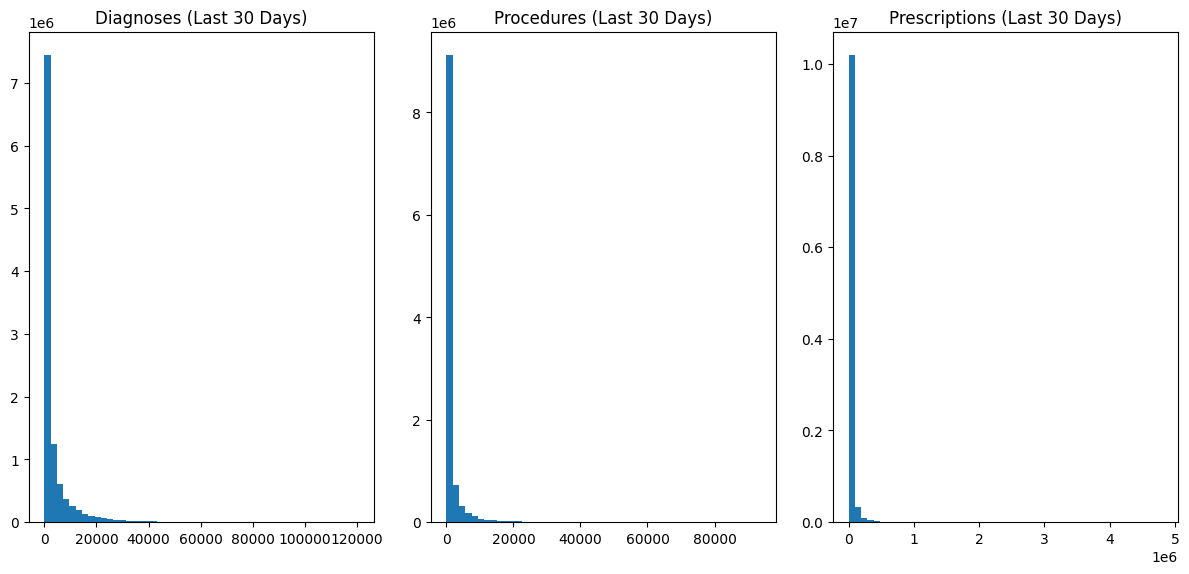

In [ ]:
import matplotlib.pyplot as plt

# Replace null values with zero
merged_data[['num_diagnoses_last_30_days',
             'num_procedures_last_30_days',
             'num_prescriptions_last_30_days']] = merged_data[
    ['num_diagnoses_last_30_days',
     'num_procedures_last_30_days',
     'num_prescriptions_last_30_days']].fillna(0)

# Distribution plots
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.hist(merged_data['num_diagnoses_last_30_days'], bins=50)
plt.title('Diagnoses (Last 30 Days)')

plt.subplot(1, 3, 2)
plt.hist(merged_data['num_procedures_last_30_days'], bins=50)
plt.title('Procedures (Last 30 Days)')

plt.subplot(1, 3, 3)
plt.hist(merged_data['num_prescriptions_last_30_days'], bins=50)
plt.title('Prescriptions (Last 30 Days)')

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

merged_data_path = '/content/drive/MyDrive/FYPData/merged_with_final_temporal_data_dict.parquet'
merged_data = pd.read_parquet(merged_data_path)

merged_data.dtypes


,0
subject_id,int32
hadm_id,int32
admittime,datetime64[ns]
dischtime,datetime64[ns]
admission_type,object
admission_location,object
discharge_location,object
insurance,object
language,object
marital_status,object


In [ ]:
import pandas as pd
import numpy as np

data_path = '/content/drive/MyDrive/FYPData/merged_with_final_temporal_data_dict.parquet'
data = pd.read_parquet(data_path)

# Ensure 'anchor_age' is in numeric format
data['anchor_age'] = pd.to_numeric(data['anchor_age'], errors='coerce')

# Add Age Bins (3 Categories)
age_bins = [65, 75, 85, np.inf]
age_labels = ['65-74', '75-84', '85+']
data['age_bin'] = pd.cut(data['anchor_age'], bins=age_bins, labels=age_labels, right=False)

# Encode Age Bins as Ordinal
data['age_bin_encoded'] = data['age_bin'].cat.codes

output_path = '/content/drive/MyDrive/FYPData/merged_with_age_features.parquet'
data.to_parquet(output_path, index=False, compression='snappy')

print(f"Updated dataset saved to: {output_path}")

print(data[['anchor_age', 'age_bin', 'age_bin_encoded']].head(10))


Updated dataset saved to: /content/drive/MyDrive/FYPData/merged_with_age_features.parquet
   anchor_age age_bin  age_bin_encoded
0        72.0   65-74                0
1        72.0   65-74                0
2        72.0   65-74                0
3        72.0   65-74                0
4        72.0   65-74                0
5        72.0   65-74                0
6        72.0   65-74                0
7        72.0   65-74                0
8        72.0   65-74                0
9        72.0   65-74                0


# Aggregating Long Format to suit for Analysis - 1 row per patient admission

In [ ]:
df = pd.read_parquet('/content/drive/MyDrive/FYPData/merged_with_age_features.parquet')
df.head(10)

,subject_id,hadm_id,admittime,dischtime,admission_type,admission_location,discharge_location,insurance,language,marital_status,race,anchor_age,mapped_diagnoses_icd9,mapped_procedures_icd9,mean_lab_value,min_lab_value,max_lab_value,total_lab_count,unique_lab_count,most_common_lab_label,proportion_abnormal,total_prescriptions,unique_drug_count,total_doses,zero_dose_proportion,polypharmacy_flag,readmitted_30d,days_since_last_discharge,num_visits_last_90_days,same_day_readmission_flag,gap_flag,length_of_stay,num_diagnoses_last_30_days,num_diagnoses_last_60_days,num_diagnoses_last_90_days,num_prescriptions_last_30_days,num_prescriptions_last_60_days,num_prescriptions_last_90_days,num_procedures_last_30_days,num_procedures_last_60_days,num_procedures_last_90_days,num_unique_diagnoses,num_unique_procedures,age_bin,age_bin_encoded
0,10000084,23052089,2160-11-21 01:56:00,2160-11-25 14:52:00,EW EMER.,WALK-IN/SELF REFERRAL,HOME HEALTH CARE,Medicare,English,MARRIED,WHITE,72.0,33182,None,NaN,NaN,NaN,NaN,NaN,None,NaN,13.0,9.0,17.0,0.230769,1.0,0,NaN,0,0,0,4,6.0,6.0,6.0,13.0,13.0,13.0,0.0,0.0,0.0,6,0,65-74,0
1,10000084,23052089,2160-11-21 01:56:00,2160-11-25 14:52:00,EW EMER.,WALK-IN/SELF REFERRAL,HOME HEALTH CARE,Medicare,English,MARRIED,WHITE,72.0,29410,None,NaN,NaN,NaN,NaN,NaN,None,NaN,13.0,9.0,17.0,0.230769,1.0,0,NaN,0,0,0,4,6.0,6.0,6.0,13.0,13.0,13.0,0.0,0.0,0.0,6,0,65-74,0
2,10000084,23052089,2160-11-21 01:56:00,2160-11-25 14:52:00,EW EMER.,WALK-IN/SELF REFERRAL,HOME HEALTH CARE,Medicare,English,MARRIED,WHITE,72.0,36816,None,NaN,NaN,NaN,NaN,NaN,None,NaN,13.0,9.0,17.0,0.230769,1.0,0,NaN,0,0,0,4,6.0,6.0,6.0,13.0,13.0,13.0,0.0,0.0,0.0,6,0,65-74,0
3,10000084,23052089,2160-11-21 01:56:00,2160-11-25 14:52:00,EW EMER.,WALK-IN/SELF REFERRAL,HOME HEALTH CARE,Medicare,English,MARRIED,WHITE,72.0,78199,None,NaN,NaN,NaN,NaN,NaN,None,NaN,13.0,9.0,17.0,0.230769,1.0,0,NaN,0,0,0,4,6.0,6.0,6.0,13.0,13.0,13.0,0.0,0.0,0.0,6,0,65-74,0
4,10000084,23052089,2160-11-21 01:56:00,2160-11-25 14:52:00,EW EMER.,WALK-IN/SELF REFERRAL,HOME HEALTH CARE,Medicare,English,MARRIED,WHITE,72.0,2724,None,NaN,NaN,NaN,NaN,NaN,None,NaN,13.0,9.0,17.0,0.230769,1.0,0,NaN,0,0,0,4,6.0,6.0,6.0,13.0,13.0,13.0,0.0,0.0,0.0,6,0,65-74,0
5,10000084,23052089,2160-11-21 01:56:00,2160-11-25 14:52:00,EW EMER.,WALK-IN/SELF REFERRAL,HOME HEALTH CARE,Medicare,English,MARRIED,WHITE,72.0,V1046,None,NaN,NaN,NaN,NaN,NaN,None,NaN,13.0,9.0,17.0,0.230769,1.0,0,NaN,0,0,0,4,6.0,6.0,6.0,13.0,13.0,13.0,0.0,0.0,0.0,6,0,65-74,0
6,10000084,29888819,2160-12-28 05:11:00,2160-12-28 16:07:00,EU OBSERVATION,PHYSICIAN REFERRAL,None,Medicare,English,MARRIED,WHITE,72.0,78097,None,NaN,NaN,NaN,NaN,NaN,None,NaN,0.0,0.0,0.0,0.000000,0.0,0,32.0,1,0,0,0,6.0,42.0,42.0,0.0,78.0,78.0,0.0,0.0,0.0,6,0,65-74,0
7,10000084,29888819,2160-12-28 05:11:00,2160-12-28 16:07:00,EU OBSERVATION,PHYSICIAN REFERRAL,None,Medicare,English,MARRIED,WHITE,72.0,3320,None,NaN,NaN,NaN,NaN,NaN,None,NaN,0.0,0.0,0.0,0.000000,0.0,0,32.0,1,0,0,0,6.0,42.0,42.0,0.0,78.0,78.0,0.0,0.0,0.0,6,0,65-74,0
8,10000084,29888819,2160-12-28 05:11:00,2160-12-28 16:07:00,EU OBSERVATION,PHYSICIAN REFERRAL,None,Medicare,English,MARRIED,WHITE,72.0,29410,None,NaN,NaN,NaN,NaN,NaN,None,NaN,0.0,0.0,0.0,0.000000,0.0,0,32.0,1,0,0,0,6.0,42.0,42.0,0.0,78.0,78.0,0.0,0.0,0.0,6,0,65-74,0
9,10000084,29888819,2160-12-28 05:11:00,2160-12-28 16:07:00,EU OBSERVATION,PHYSICIAN REFERRAL,None,Medicare,English,MARRIED,WHITE,72.0,7823,None,NaN,NaN,NaN,NaN,NaN,None,NaN,0.0,0.0,0.0,0.000000,0.0,0,32.0,1,0,0,0,6.0,42.0,42.0,0.0,78.0,78.0,0.0,0.0,0.0,6,0,65-74,0


In [ ]:
import pandas as pd

def unique_join(series):
    """
    Returns a space-separated string of unique, sorted codes from a Series.
    Ignores None/NaN or literal 'None'.
    """
    unique_codes = set(series.dropna().astype(str))
    unique_codes = {code for code in unique_codes if code.lower() != 'none'}
    return ' '.join(sorted(unique_codes))

# Identify long format features
long_format_features = ['mapped_diagnoses_icd9', 'mapped_procedures_icd9']

# Group and aggregate long-format codes
diagnosis_procedure_agg = (
    df.groupby('hadm_id')[long_format_features]
      .agg(unique_join)
)

# Take the first occurrence of all other columns
other_features = [col for col in df.columns if col not in long_format_features]
static_info_agg = (
    df[other_features]
      .drop_duplicates(subset='hadm_id')
      .set_index('hadm_id')
)

# Merge both parts back together
df_agg = (
    static_info_agg
    .join(diagnosis_procedure_agg, how='left')
    .reset_index()
)

# Final check
assert df_agg['hadm_id'].is_unique, "Aggregation failed. Duplicate hadm_ids remain."

print(" Aggregation complete. One row per admission.")
print("Final shape:", df_agg.shape)



 Aggregation complete. One row per admission.
Final shape: (205456, 45)


In [ ]:
df_agg.head(10)

,hadm_id,subject_id,admittime,dischtime,admission_type,admission_location,discharge_location,insurance,language,marital_status,race,anchor_age,mean_lab_value,min_lab_value,max_lab_value,total_lab_count,unique_lab_count,most_common_lab_label,proportion_abnormal,total_prescriptions,unique_drug_count,total_doses,zero_dose_proportion,polypharmacy_flag,readmitted_30d,days_since_last_discharge,num_visits_last_90_days,same_day_readmission_flag,gap_flag,length_of_stay,num_diagnoses_last_30_days,num_diagnoses_last_60_days,num_diagnoses_last_90_days,num_prescriptions_last_30_days,num_prescriptions_last_60_days,num_prescriptions_last_90_days,num_procedures_last_30_days,num_procedures_last_60_days,num_procedures_last_90_days,num_unique_diagnoses,num_unique_procedures,age_bin,age_bin_encoded,mapped_diagnoses_icd9,mapped_procedures_icd9
0,23052089,10000084,2160-11-21 01:56:00,2160-11-25 14:52:00,EW EMER.,WALK-IN/SELF REFERRAL,HOME HEALTH CARE,Medicare,English,MARRIED,WHITE,72.0,NaN,NaN,NaN,NaN,NaN,None,NaN,13.0,9.0,17.0,0.230769,1.0,0,NaN,0,0,0,4,6.0,6.0,6.0,13.0,13.0,13.0,0.0,0.0,0.0,6,0,65-74,0,2724 29410 33182 36816 78199 V1046,
1,29888819,10000084,2160-12-28 05:11:00,2160-12-28 16:07:00,EU OBSERVATION,PHYSICIAN REFERRAL,None,Medicare,English,MARRIED,WHITE,72.0,NaN,NaN,NaN,NaN,NaN,None,NaN,0.0,0.0,0.0,0.000000,0.0,0,32.0,1,0,0,0,6.0,42.0,42.0,0.0,78.0,78.0,0.0,0.0,0.0,6,0,65-74,0,2724 29410 3320 78097 7823 V1046,
2,20642640,10000635,2143-12-23 14:55:00,2143-12-24 12:52:00,EU OBSERVATION,WALK-IN/SELF REFERRAL,None,Medicare,English,WIDOWED,BLACK/AFRICAN AMERICAN,74.0,NaN,NaN,NaN,NaN,NaN,None,NaN,0.0,0.0,0.0,0.000000,0.0,0,2742.0,1,0,1,0,3.0,3.0,3.0,15.0,15.0,15.0,3.0,3.0,3.0,10,0,65-74,0,25000 27800 4010 4011 4019 4270 78194 7820 786...,
3,26134563,10000635,2136-06-19 14:24:00,2136-06-20 11:30:00,AMBULATORY OBSERVATION,PROCEDURE SITE,None,Medicare,English,WIDOWED,BLACK/AFRICAN AMERICAN,74.0,NaN,NaN,NaN,NaN,NaN,None,NaN,15.0,13.0,9.0,0.666667,1.0,0,NaN,0,0,0,0,30.0,30.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,3,3,65-74,0,25000 4019 42789,3727 3728 3734
4,23280645,10000690,2150-09-16 19:48:00,2150-09-24 13:50:00,EW EMER.,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,English,WIDOWED,WHITE,86.0,NaN,NaN,NaN,NaN,NaN,None,NaN,61.0,37.0,64.0,0.295082,1.0,0,71.0,1,0,0,7,18.0,18.0,18.0,28.0,28.0,28.0,0.0,0.0,0.0,15,0,85+,2,2764 2767 2859 3004 33394 4019 4271 4280 42833...,
5,25860671,10000690,2150-11-02 18:02:00,2150-11-12 13:45:00,EW EMER.,EMERGENCY ROOM,REHAB,Medicare,English,WIDOWED,WHITE,86.0,NaN,NaN,NaN,NaN,NaN,None,NaN,77.0,37.0,93.0,0.259740,1.0,0,39.0,2,0,0,9,120.0,120.0,201.0,488.0,488.0,614.0,0.0,0.0,0.0,22,1,85+,2,2763 2859 3004 33394 4019 41401 4240 42731 427...,3893
6,26146595,10000690,2152-01-28 23:40:00,2152-01-30 15:56:00,EW EMER.,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,English,WIDOWED,WHITE,86.0,NaN,NaN,NaN,NaN,NaN,None,NaN,20.0,18.0,19.0,0.500000,1.0,0,442.0,3,0,1,1,330.0,555.0,555.0,1155.0,2070.0,2070.0,15.0,15.0,15.0,17,1,85+,2,1539 2930 2948 3004 33394 4011 42731 4280 4283...,4524
7,26504700,10000690,2150-07-03 02:46:00,2150-07-07 15:42:00,EW EMER.,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,English,WIDOWED,WHITE,86.0,56.396510,0.03,1489.0,129.0,34.0,Anion Gap,0.294574,14.0,10.0,12.0,0.285714,1.0,0,NaN,0,0,0,4,170.0,170.0,170.0,200.0,200.0,200.0,10.0,10.0,10.0,9,0,85+,2,3899 4019 4240 4280 42833 45981 7821 7837 78720,
8,27897940,10000764,2132-10-14 23:31:00,2132-10-19 16:30:00,URGENT,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Medicare,English,SINGLE,WHITE,86.0,63.494198,0.00,1036.0,133.0,59.0,Hematocrit,0.406015,23.0,17.0,38.0,0.217391,1.0,0,NaN,0,0,0,4,38.0,38.0,38.0,46.0,46.0,46.0,0.0,0.0,0.0,19,0,85+,2,2720 2724 2875 28860 4019 41071 412 41401 4241...,
9,20897796,10000980,2193-08-15 01:01:00,2193-08-17 15:07:00,OBSERVATION ADMIT,WALK-IN/SELF REFERRAL,HOME HEALTH CARE,Medicare,English,MARRIED,BLACK/AFRICAN AMERICAN,73.0,72.261955,-5.00,4512.0,128.0,53.0,H,0.343750,32.0,21.0,29.0,0.343750,1.0,0,757.0,6,0,1,2,22.0,22.0,22.0,9

In [ ]:
df_agg.dtypes

,0
hadm_id,int32
subject_id,int32
admittime,datetime64[ns]
dischtime,datetime64[ns]
admission_type,object
admission_location,object
discharge_location,object
insurance,object
language,object
marital_status,object


In [ ]:
df_agg.to_parquet('/content/drive/MyDrive/FYPData/data_aggregated_before_imputation.parquet')

# Imputation

This applies strategic categorical data imputation and introduces missing value indicators to improve model robustness.

For categorical variables like admission type, race, and discharge location, mode imputation ensures missing values are filled with the most common category - preserving dominant trends in the data.

For features where missing values may hold clinical significance (e.g., insurance, language, marital status), assigning the label 'Unknown' avoids injecting artificial patterns while still providing meaningful representation.

Additionally, by adding missing value indicator columns, the model can explicitly learn whether the absence of information itself is predictive. This combined approach enhances data completeness while maintaining critical insights for improved readmission prediction performance

In [ ]:
import pandas as pd
import numpy as np

data_path = '/content/drive/MyDrive/FYPData/data_aggregated_before_imputation.parquet'
data = pd.read_parquet(data_path)

# Mode Imputation for Categorical Fields
mode_impute_cols = ['admission_type', 'admission_location', 'discharge_location', 'race']
for col in mode_impute_cols:
    data[col].fillna(data[col].mode()[0], inplace=True)

# 'Unknown' Replacement for Optional Categorical Fields
unknown_replace_cols = ['insurance', 'language', 'marital_status', 'most_common_lab_label']
for col in unknown_replace_cols:
    data[col].fillna('Unknown', inplace=True)

# Add Missing Indicator Columns for Informative Categorical Features
indicator_categorical_cols = ['insurance', 'language', 'marital_status']
for col in indicator_categorical_cols:
    data[f'{col}_missing'] = data[col].isna().astype(int)

# Add Missing Indicators for Key Numerical Features (optional but research-backed)
indicator_numeric_cols = ['mean_lab_value', 'min_lab_value', 'max_lab_value', 'days_since_last_discharge']
for col in indicator_numeric_cols:
    data[f'{col}_missing'] = data[col].isna().astype(int)

# Median Imputation for Risk-Related Continuous Features
median_impute_cols = [
    'mean_lab_value', 'min_lab_value', 'max_lab_value',
    'days_since_last_discharge', 'length_of_stay',
    'proportion_abnormal'
]
for col in median_impute_cols:
    data[col].fillna(data[col].median(), inplace=True)

# Zero Imputation for Count-Based and Flag Features
zero_impute_cols = [
    'total_lab_count', 'unique_lab_count', 'total_prescriptions',
    'unique_drug_count', 'total_doses', 'zero_dose_proportion',
    'polypharmacy_flag', 'num_visits_last_90_days',
    'same_day_readmission_flag', 'gap_flag', 'num_diagnoses_last_30_days',
    'num_diagnoses_last_60_days', 'num_diagnoses_last_90_days',
    'num_prescriptions_last_30_days', 'num_prescriptions_last_60_days',
    'num_prescriptions_last_90_days', 'num_procedures_last_30_days',
    'num_procedures_last_60_days', 'num_procedures_last_90_days',
    'num_unique_diagnoses', 'num_unique_procedures'
]
for col in zero_impute_cols:
    data[col].fillna(0, inplace=True)

# Optimize Integer Columns for Memory
int_cols = ['num_visits_last_90_days', 'same_day_readmission_flag',
            'gap_flag', 'length_of_stay', 'num_unique_diagnoses',
            'num_unique_procedures']
data[int_cols] = data[int_cols].astype('int16')

# Clean-up text-based
data['mapped_diagnoses_icd9'] = data['mapped_diagnoses_icd9'].fillna('').replace('None', '')
data['mapped_procedures_icd9'] = data['mapped_procedures_icd9'].fillna('').replace('None', '')

output_path = '/content/drive/MyDrive/FYPData/merged_with_imputed_all.parquet'
data.to_parquet(output_path, index=False, compression='snappy')

# Final Check
print(f" Updated dataset saved to: {output_path}")
print(data[median_impute_cols + zero_impute_cols +
           [f'{col}_missing' for col in indicator_categorical_cols + indicator_numeric_cols]].head(10))



<ipython-input-27-c022132167e8>:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mode()[0], inplace=True)
<ipython-input-27-c022132167e8>:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try

 Updated dataset saved to: /content/drive/MyDrive/FYPData/merged_with_imputed_all.parquet
   mean_lab_value  min_lab_value  max_lab_value  days_since_last_discharge  length_of_stay  proportion_abnormal  total_lab_count  unique_lab_count  total_prescriptions  unique_drug_count  total_doses  zero_dose_proportion  polypharmacy_flag  num_visits_last_90_days  same_day_readmission_flag  gap_flag  num_diagnoses_last_30_days  num_diagnoses_last_60_days  num_diagnoses_last_90_days  num_prescriptions_last_30_days  num_prescriptions_last_60_days  num_prescriptions_last_90_days  num_procedures_last_30_days  num_procedures_last_60_days  num_procedures_last_90_days  num_unique_diagnoses  num_unique_procedures  insurance_missing  language_missing  marital_status_missing  mean_lab_value_missing  min_lab_value_missing  max_lab_value_missing  days_since_last_discharge_missing
0       43.883540           0.02          331.0                       93.0               4             0.342466              0.0 

In [ ]:
missing_summary = data.isnull().sum()
print("Missing columns:\n", missing_summary[missing_summary > 0])


Missing columns:
 Series([], dtype: int64)


In [ ]:
print("Min/max values for critical features:")
for col in ['mean_lab_value', 'min_lab_value', 'max_lab_value', 'proportion_abnormal']:
    print(f"{col}: min={data[col].min()}, max={data[col].max()}")


Min/max values for critical features:
mean_lab_value: min=-260.83243, max=80834.08
min_lab_value: min=-1048.0, max=4350.0
max_lab_value: min=0.0, max=4422000.0
proportion_abnormal: min=0.0, max=2.5


In [ ]:
print("Unique values in mapped_diagnoses_icd9:", data['mapped_diagnoses_icd9'].unique()[:5])
print("Empty diagnosis rows:", (data['mapped_diagnoses_icd9'] == '').sum())


Unique values in mapped_diagnoses_icd9: ['2724 29410 33182 36816 78199 V1046' '2724 29410 3320 78097 7823 V1046'
 '25000 27800 4010 4011 4019 4270 78194 7820 78659 No Mapping'
 '25000 4019 42789'
 '2764 2767 2859 3004 33394 4019 4271 4280 42833 4589 45981 486 71590 73300 73730']
Empty diagnosis rows: 136


In [ ]:
print("Class distribution (readmitted_30d):")
print(data['readmitted_30d'].value_counts(normalize=True))


Class distribution (readmitted_30d):
readmitted_30d
0    0.809638
1    0.190362
Name: proportion, dtype: float64


In [ ]:
import pandas as pd

data_path = '/content/drive/MyDrive/FYPData/merged_with_imputed_all.parquet'
data = pd.read_parquet(data_path)

# Clip mean_lab_value to remove extreme lab averages (0.5th–99.5th percentile)
data['mean_lab_value'] = data['mean_lab_value'].clip(
    lower=data['mean_lab_value'].quantile(0.005),
    upper=data['mean_lab_value'].quantile(0.995)
)

# Clip min/max lab values to physiologically plausible bounds
data['min_lab_value'] = data['min_lab_value'].clip(lower=0, upper=2000)
data['max_lab_value'] = data['max_lab_value'].clip(lower=0, upper=2000)

# Cap proportion_abnormal to 1.0 (100%)
data['proportion_abnormal'] = data['proportion_abnormal'].clip(upper=1.0)

output_path = '/content/drive/MyDrive/FYPData/merged_with_clipped_labs.parquet'
data.to_parquet(output_path, index=False, compression='snappy')

print(f" Clipped and saved dataset to: {output_path}")



 Clipped and saved dataset to: /content/drive/MyDrive/FYPData/merged_with_clipped_labs.parquet


In [ ]:
data.dtypes

,0
hadm_id,int32
subject_id,int32
admittime,datetime64[ns]
dischtime,datetime64[ns]
admission_type,object
admission_location,object
discharge_location,object
insurance,object
language,object
marital_status,object


# EDA (Exploratory Data Analysis)

In [ ]:
pip install pyarrow


In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/FYPData/merged_with_clipped_labs.parquet'
df = pd.read_parquet(file_path)

df.head()


,hadm_id,subject_id,admittime,dischtime,admission_type,admission_location,discharge_location,insurance,language,marital_status,race,anchor_age,mean_lab_value,min_lab_value,max_lab_value,total_lab_count,unique_lab_count,most_common_lab_label,proportion_abnormal,total_prescriptions,unique_drug_count,total_doses,zero_dose_proportion,polypharmacy_flag,readmitted_30d,days_since_last_discharge,num_visits_last_90_days,same_day_readmission_flag,gap_flag,length_of_stay,num_diagnoses_last_30_days,num_diagnoses_last_60_days,num_diagnoses_last_90_days,num_prescriptions_last_30_days,num_prescriptions_last_60_days,num_prescriptions_last_90_days,num_procedures_last_30_days,num_procedures_last_60_days,num_procedures_last_90_days,num_unique_diagnoses,num_unique_procedures,age_bin,age_bin_encoded,mapped_diagnoses_icd9,mapped_procedures_icd9,insurance_missing,language_missing,marital_status_missing,mean_lab_value_missing,min_lab_value_missing,max_lab_value_missing,days_since_last_discharge_missing
0,23052089,10000084,2160-11-21 01:56:00,2160-11-25 14:52:00,EW EMER.,WALK-IN/SELF REFERRAL,HOME HEALTH CARE,Medicare,English,MARRIED,WHITE,72.0,43.88354,0.02,331.0,0.0,0.0,Unknown,0.342466,13.0,9.0,17.0,0.230769,1.0,0,93.0,0,0,0,4,6.0,6.0,6.0,13.0,13.0,13.0,0.0,0.0,0.0,6,0,65-74,0,2724 29410 33182 36816 78199 V1046,,0,0,0,1,1,1,1
1,29888819,10000084,2160-12-28 05:11:00,2160-12-28 16:07:00,EU OBSERVATION,PHYSICIAN REFERRAL,HOME HEALTH CARE,Medicare,English,MARRIED,WHITE,72.0,43.88354,0.02,331.0,0.0,0.0,Unknown,0.342466,0.0,0.0,0.0,0.000000,0.0,0,32.0,1,0,0,0,6.0,42.0,42.0,0.0,78.0,78.0,0.0,0.0,0.0,6,0,65-74,0,2724 29410 3320 78097 7823 V1046,,0,0,0,1,1,1,0
2,20642640,10000635,2143-12-23 14:55:00,2143-12-24 12:52:00,EU OBSERVATION,WALK-IN/SELF REFERRAL,HOME HEALTH CARE,Medicare,English,WIDOWED,BLACK/AFRICAN AMERICAN,74.0,43.88354,0.02,331.0,0.0,0.0,Unknown,0.342466,0.0,0.0,0.0,0.000000,0.0,0,2742.0,1,0,1,0,3.0,3.0,3.0,15.0,15.0,15.0,3.0,3.0,3.0,10,0,65-74,0,25000 27800 4010 4011 4019 4270 78194 7820 786...,,0,0,0,1,1,1,0
3,26134563,10000635,2136-06-19 14:24:00,2136-06-20 11:30:00,AMBULATORY OBSERVATION,PROCEDURE SITE,HOME HEALTH CARE,Medicare,English,WIDOWED,BLACK/AFRICAN AMERICAN,74.0,43.88354,0.02,331.0,0.0,0.0,Unknown,0.342466,15.0,13.0,9.0,0.666667,1.0,0,93.0,0,0,0,0,30.0,30.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,3,3,65-74,0,25000 4019 42789,3727 3728 3734,0,0,0,1,1,1,1
4,23280645,10000690,2150-09-16 19:48:00,2150-09-24 13:50:00,EW EMER.,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,English,WIDOWED,WHITE,86.0,43.88354,0.02,331.0,0.0,0.0,Unknown,0.342466,61.0,37.0,64.0,0.295082,1.0,0,71.0,1,0,0,7,18.0,18.0,18.0,28.0,28.0,28.0,0.0,0.0,0.0,15,0,85+,2,2764 2767 2859 3004 33394 4019 4271 4280 42833...,,0,0,0,1,1,1,0


In [ ]:
print("Dataset Shape:", df.shape)
print("\nData Types:\n", df.dtypes)

print("\nMissing Values:\n", df.isnull().sum())

df.describe(include='all')


Dataset Shape: (205456, 52)

Data Types:
 hadm_id                                       int32
subject_id                                    int32
admittime                            datetime64[ns]
dischtime                            datetime64[ns]
admission_type                               object
admission_location                           object
discharge_location                           object
insurance                                    object
language                                     object
marital_status                               object
race                                         object
anchor_age                                  float32
mean_lab_value                              float64
min_lab_value                               float32
max_lab_value                               float64
total_lab_count                             float32
unique_lab_count                            float32
most_common_lab_label                        object
proportion_abnormal   

,hadm_id,subject_id,admittime,dischtime,admission_type,admission_location,discharge_location,insurance,language,marital_status,race,anchor_age,mean_lab_value,min_lab_value,max_lab_value,total_lab_count,unique_lab_count,most_common_lab_label,proportion_abnormal,total_prescriptions,unique_drug_count,total_doses,zero_dose_proportion,polypharmacy_flag,readmitted_30d,days_since_last_discharge,num_visits_last_90_days,same_day_readmission_flag,gap_flag,length_of_stay,num_diagnoses_last_30_days,num_diagnoses_last_60_days,num_diagnoses_last_90_days,num_prescriptions_last_30_days,num_prescriptions_last_60_days,num_prescriptions_last_90_days,num_procedures_last_30_days,num_procedures_last_60_days,num_procedures_last_90_days,num_unique_diagnoses,num_unique_procedures,age_bin,age_bin_encoded,mapped_diagnoses_icd9,mapped_procedures_icd9,insurance_missing,language_missing,marital_status_missing,mean_lab_value_missing,min_lab_value_missing,max_lab_value_missing,days_since_last_discharge_missing
count,2.054560e+05,2.054560e+05,205456,205456,205456,205456,205456,205456,205456,205456,205456,205456.000000,205456.000000,205456.000000,205456.000000,205456.00000,205456.000000,205456,205456.000000,205456.000000,205456.000000,205456.000000,205456.000000,205456.000000,205456.000000,205456.000000,205456.000000,205456.000000,205456.000000,205456.000000,205456.000000,205456.000000,205456.000000,2.054560e+05,2.054560e+05,2.054560e+05,205456.000000,205456.000000,205456.000000,205456.000000,205456.000000,205456,205456.000000,205456,205456,205456.0,205456.0,205456.0,205456.000000,205456.000000,205456.000000,205456.000000
unique,NaN,NaN,NaN,NaN,9,11,13,6,26,5,33,NaN,NaN,NaN,NaN,NaN,NaN,141,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,203155,41778,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,Medicare,English,MARRIED,WHITE,NaN,NaN,NaN,NaN,NaN,NaN,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65-74,NaN,78650,,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,80271,93475,91132,174642,177188,97754,139720,NaN,NaN,NaN,NaN,NaN,NaN,113481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,96067,NaN,231,93204,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2.499260e+07,1.500486e+07,2155-02-28 17:03:34.630189056,2155-03-06 00:49:59.649560576,NaN,NaN,NaN,NaN,NaN,NaN,NaN,76.245171,46.792598,0.232401,441.365181,85.12616,21.424885,NaN,0.340811,43.408438,23.931241,41.311089,0.347677,0.912171,0.190362,250.347792,2.519542,0.011511,0.159421,4.763249,3408.222826,3709.306805,3907.578255,2.078789e+04,2.215306e+04,2.308708e+04,1255.302902,1340.593874,1391.934015,16.332446,1.921974,NaN,0.714498,NaN,NaN,0.0,0.0,0.0,0.552337,0.552337,0.552337,0.401424
min,2.000002e+07,1.000008e+07,2109-12-14 22:50:00,2110-01-13 18:40:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65.000000,15.233781,0.000000,0.000000,0.00000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,NaN,NaN,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000
25%,2.249370e+07,1.250122e+07,2135-03-10 20:17:15.000000512,2135-03-15 17:02:30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.000000,43.883540,0.020000,331.000000,0.00000,0.000000,NaN,0.342466,17.000000,14.000000,16.000000,0.243902,1.000000,0.000000,56.000000,0.000000,0.000000,0.000000,1.000000,140.000000,156.000000,168.000000,2.700000e+02,3.060000e+02,3.300000e+02,4.000000,6.000000,7.000000,10.000000,0.000000,NaN,0.000000,NaN,NaN,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000
50%,2.498982e+07,1.501191e+07,2154-12-20 20:45:00,2154-12-24 18:37:30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75.000000,43.883540,0.020000,331.000000,0.00000,0.000000,NaN,0.342466,28.000000,21.000000,28.000000,0.354167,1.000000,0.000000,93.000000,1.000000,0.000000,0.000000,3.00000

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('/content/drive/MyDrive/FYPData/EDA_plots', exist_ok=True)

df = pd.read_parquet('/content/drive/MyDrive/FYPData/merged_with_clipped_labs.parquet')

# Define relevant numerical columns
numerical_cols = [
    'anchor_age', 'mean_lab_value', 'min_lab_value', 'max_lab_value',
    'total_lab_count', 'unique_lab_count', 'proportion_abnormal',
    'total_prescriptions', 'unique_drug_count', 'total_doses',
    'zero_dose_proportion', 'polypharmacy_flag', 'days_since_last_discharge',
    'num_visits_last_90_days', 'length_of_stay', 'num_diagnoses_last_30_days',
    'num_diagnoses_last_60_days', 'num_diagnoses_last_90_days',
    'num_prescriptions_last_30_days', 'num_prescriptions_last_60_days',
    'num_prescriptions_last_90_days', 'num_procedures_last_30_days',
    'num_procedures_last_60_days', 'num_procedures_last_90_days',
    'num_unique_diagnoses', 'num_unique_procedures'
]

# Set seaborn style for clean plots
sns.set_theme(style="whitegrid")
sns.set_palette("deep")
sns.set(font_scale=1.1)

# Plot 1: Age Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['anchor_age'], bins=30, kde=True)
plt.title('Age Distribution of Elderly Patients (65+)', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Number of Admissions', fontsize=12)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/FYPData/EDA_plots/age_distribution.png', dpi=300)
plt.close()

# Plot 2: Readmission Rate
plt.figure(figsize=(5, 5))
readmit_counts = df['readmitted_30d'].value_counts(normalize=True)
sns.barplot(x=readmit_counts.index, y=readmit_counts.values)
plt.xticks([0, 1], ['Not Readmitted', 'Readmitted'])
plt.ylabel('Proportion of Admissions', fontsize=12)
plt.title('30-Day Readmission Rate', fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/FYPData/EDA_plots/readmission_rate.png', dpi=300)
plt.close()

# Plot 3: Correlation Heatmap
plt.figure(figsize=(16, 12))
corr = df[numerical_cols].corr()
sns.heatmap(corr, cmap='coolwarm', center=0, square=True,
            cbar_kws={"shrink": 0.6}, linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/FYPData/EDA_plots/correlation_heatmap.png', dpi=300)
plt.close()

print(" EDA plots saved to: /content/drive/MyDrive/FYPData/EDA_plots")




 EDA plots saved to: /content/drive/MyDrive/FYPData/EDA_plots


In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

df

# Define categorical columns
categorical_cols = [
    'admission_type', 'admission_location', 'discharge_location',
    'insurance', 'language', 'marital_status', 'race',
    'most_common_lab_label'
]

# Output directory
output_dir = '/content/drive/MyDrive/FYPData/EDA_plots/categorical_vs_readmission'
os.makedirs(output_dir, exist_ok=True)

# Seaborn styling
sns.set_theme(style="whitegrid")
sns.set_palette("deep")
sns.set(font_scale=1.1)

def plot_categorical_vs_readmission():
    for col in categorical_cols:
        if df[col].nunique() <= 20:
            plt.figure(figsize=(12, 6))
            sns.barplot(
                data=df, x=col, y='readmitted_30d',
                estimator=lambda x: sum(x)/len(x),
                errorbar="ci"
            )
            plt.title(f'30-Day Readmission Rate by {col}', fontsize=14)
            plt.ylabel('Readmission Rate', fontsize=12)
            plt.xlabel(col.replace('_', ' ').title(), fontsize=12)
            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()

            # Save figure
            filename = f'{col}_vs_readmission.png'
            filepath = os.path.join(output_dir, filename)
            plt.savefig(filepath, dpi=300)
            plt.close()

    print(f" All categorical readmission plots saved to: {output_dir}")

# Run the function
plot_categorical_vs_readmission()




 All categorical readmission plots saved to: /content/drive/MyDrive/FYPData/EDA_plots/categorical_vs_readmission


In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

output_dir = '/content/drive/MyDrive/FYPData/EDA_plots/boxplots_vs_readmission'
os.makedirs(output_dir, exist_ok=True)

# List of features to compare with readmission
boxplot_features = [
    'length_of_stay',
    'total_lab_count',
    'proportion_abnormal',
    'total_prescriptions',
    'num_visits_last_90_days',
    'days_since_last_discharge'
]

# Seaborn style
sns.set_theme(style="whitegrid")
sns.set(font_scale=1.1)

# Plot each boxplot and save
for feature in boxplot_features:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x='readmitted_30d', y=feature)
    plt.title(f'{feature.replace("_", " ").title()} by Readmission Status', fontsize=14)
    plt.xlabel('Readmitted (0 = No, 1 = Yes)', fontsize=12)
    plt.ylabel(feature.replace("_", " ").title(), fontsize=12)
    plt.tight_layout()

    # Save plot
    filename = f'{feature}_by_readmission.png'
    filepath = os.path.join(output_dir, filename)
    plt.savefig(filepath, dpi=300)
    plt.close()

print(f" All boxplots saved to: {output_dir}")



 All boxplots saved to: /content/drive/MyDrive/FYPData/EDA_plots/boxplots_vs_readmission


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

output_dir = "/content/drive/MyDrive/FYPData/EDA_plots/individual_codes"
os.makedirs(output_dir, exist_ok=True)

# Explode individual ICD-9 codes
diag_df = df[['readmitted_30d', 'mapped_diagnoses_icd9']].dropna()
diag_df['mapped_diagnoses_icd9'] = diag_df['mapped_diagnoses_icd9'].astype(str)
diag_exploded = diag_df.assign(
    icd9_code=diag_df['mapped_diagnoses_icd9'].str.split()
).explode('icd9_code')

# Top individual codes by frequency
top_diags = diag_exploded['icd9_code'].value_counts().nlargest(10).index
top_diag_df = diag_exploded[diag_exploded['icd9_code'].isin(top_diags)]

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_diag_df,
    x='icd9_code',
    y='readmitted_30d',
    estimator=lambda x: sum(x)/len(x),
    errorbar='ci'
)
plt.title('30-Day Readmission Rate by Top 10 Individual Diagnoses (ICD-9)', fontsize=14)
plt.xlabel('ICD-9 Diagnosis Code', fontsize=12)
plt.ylabel('Readmission Rate', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'readmission_by_icd9_diagnoses.png'), dpi=300)
plt.close()
print(" Saved: individual diagnosis readmission plot")



 Saved: individual diagnosis readmission plot


In [ ]:
proc_df = df[['readmitted_30d', 'mapped_procedures_icd9']].dropna()
proc_df['mapped_procedures_icd9'] = proc_df['mapped_procedures_icd9'].astype(str)
proc_exploded = proc_df.assign(
    icd9_code=proc_df['mapped_procedures_icd9'].str.split()
).explode('icd9_code')

top_procs = proc_exploded['icd9_code'].value_counts().nlargest(10).index
top_proc_df = proc_exploded[proc_exploded['icd9_code'].isin(top_procs)]

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_proc_df,
    x='icd9_code',
    y='readmitted_30d',
    estimator=lambda x: sum(x)/len(x),
    errorbar='ci'
)
plt.title('30-Day Readmission Rate by Top 10 Individual Procedures (ICD-9)', fontsize=14)
plt.xlabel('ICD-9 Procedure Code', fontsize=12)
plt.ylabel('Readmission Rate', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'readmission_by_icd9_procedures.png'), dpi=300)
plt.close()
print(" Saved: individual procedure readmission plot")


 Saved: individual procedure readmission plot


In [ ]:
# Diagnoses
total_diags = df['mapped_diagnoses_icd9'].shape[0]
no_map_diags = df[df['mapped_diagnoses_icd9'] == 'No Mapping'].shape[0]
print(f"No Mapping in Diagnoses: {no_map_diags} of {total_diags} ({no_map_diags/total_diags:.2%})")

# Procedures
total_procs = df['mapped_procedures_icd9'].shape[0]
no_map_procs = df[df['mapped_procedures_icd9'] == 'No Mapping'].shape[0]
print(f"No Mapping in Procedures: {no_map_procs} of {total_procs} ({no_map_procs/total_procs:.2%})")


No Mapping in Diagnoses: 8 of 205456 (0.00%)
No Mapping in Procedures: 1143 of 205456 (0.56%)


<ipython-input-51-d5943dc9a8b5>:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=df, x='readmitted_30d', y='unique_drug_count', ci='sd', color='steelblue')


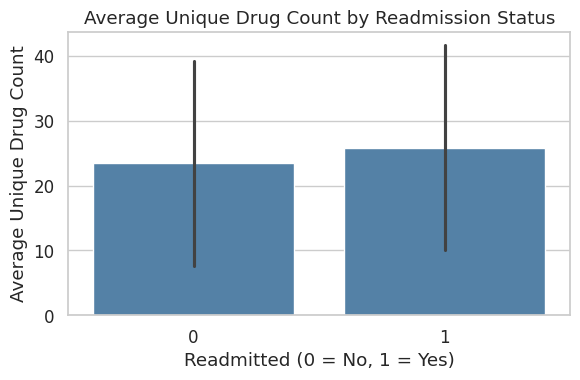

<ipython-input-51-d5943dc9a8b5>:26: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(


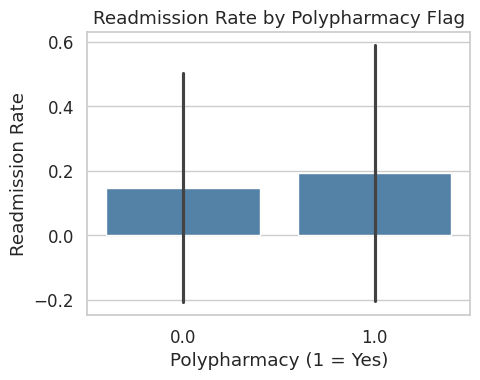

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

output_dir = "/content/drive/MyDrive/FYPData/EDA_plots/"
os.makedirs(output_dir, exist_ok=True)

sns.set_theme(style="whitegrid")
sns.set_context("notebook", font_scale=1.1)

# 1. Average Unique Drug Count by Readmission Status
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='readmitted_30d', y='unique_drug_count', ci='sd', color='steelblue')
plt.title('Average Unique Drug Count by Readmission Status')
plt.xlabel('Readmitted (0 = No, 1 = Yes)')
plt.ylabel('Average Unique Drug Count')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "unique_drug_count_by_readmission.png"), dpi=300)
plt.show()

# 2. Readmission Rate by Polypharmacy Flag
if 'polypharmacy_flag' in df.columns:
    plt.figure(figsize=(5, 4))
    sns.barplot(
        data=df,
        x='polypharmacy_flag',
        y='readmitted_30d',
        estimator=lambda x: sum(x) / len(x),
        ci='sd',
        color='steelblue'
    )
    plt.title('Readmission Rate by Polypharmacy Flag')
    plt.xlabel('Polypharmacy (1 = Yes)')
    plt.ylabel('Readmission Rate')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "readmission_by_polypharmacy_flag.png"), dpi=300)
    plt.show()




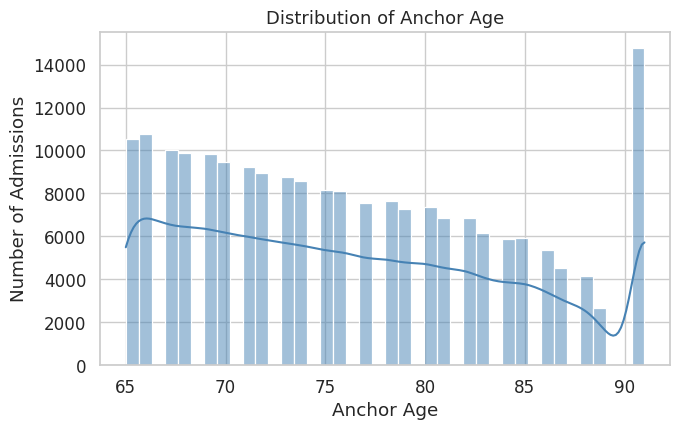

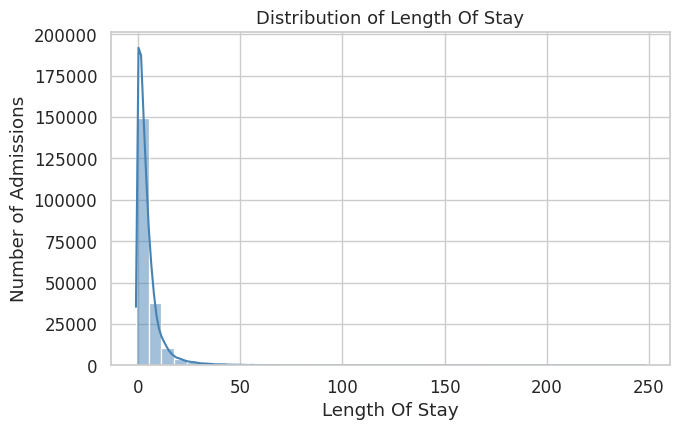

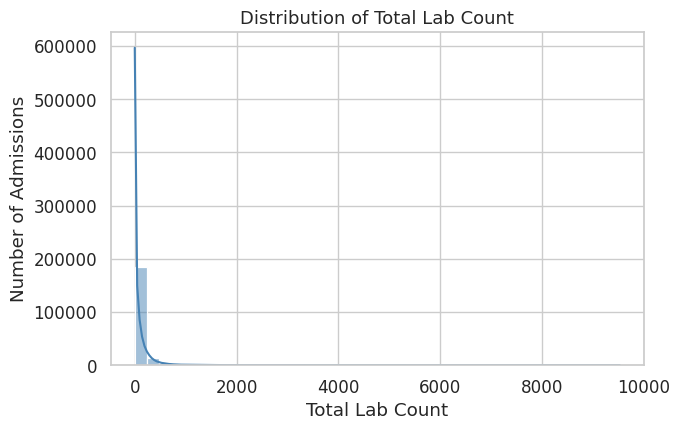

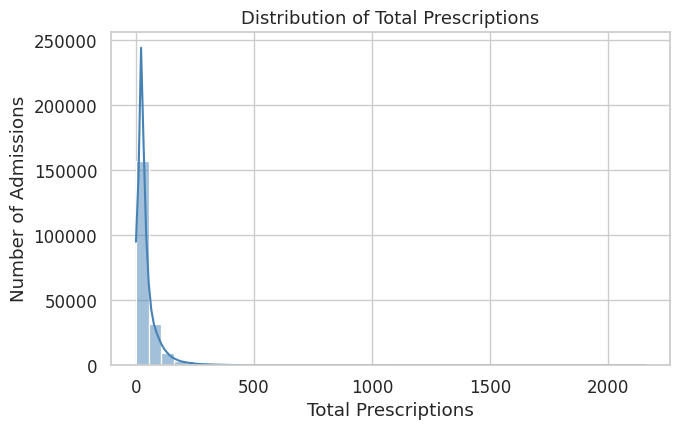

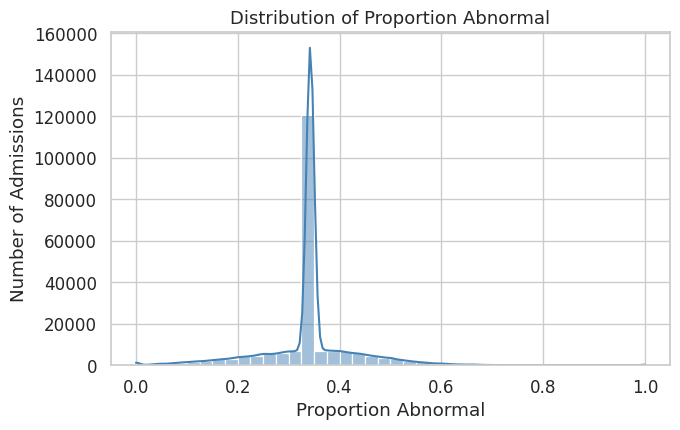

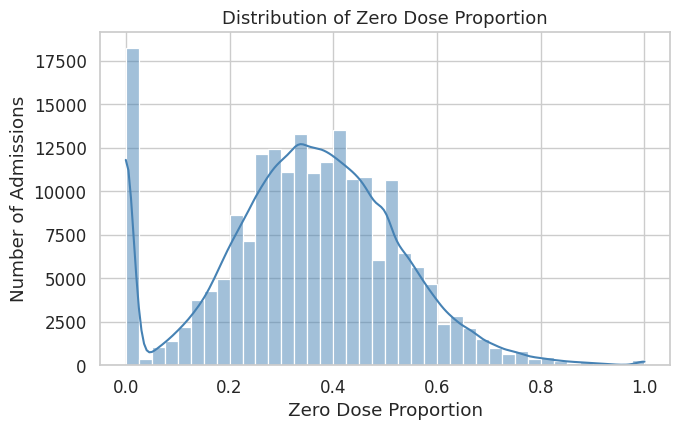

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

output_dir = "/content/drive/MyDrive/FYPData/EDA_plots/"
os.makedirs(output_dir, exist_ok=True)

sns.set_theme(style="whitegrid")
sns.set_context("notebook", font_scale=1.1)

# Features to visualize
dist_features = [
    'anchor_age', 'length_of_stay', 'total_lab_count',
    'total_prescriptions', 'proportion_abnormal', 'zero_dose_proportion'
]

# Plot each and save
for feature in dist_features:
    plt.figure(figsize=(7, 4.5))
    sns.histplot(df[feature], bins=40, kde=True, color='steelblue')
    plt.title(f'Distribution of {feature.replace("_", " ").title()}', fontsize=13)
    plt.xlabel(feature.replace("_", " ").title())
    plt.ylabel('Number of Admissions')
    plt.tight_layout()

    # Save as PNG
    filename = f"{feature}_distribution.png"
    plt.savefig(os.path.join(output_dir, filename), dpi=300)
    plt.show()



In [ ]:
from scipy.stats import pointbiserialr
import pandas as pd
import os

numerical_cols = [
    'anchor_age', 'mean_lab_value', 'min_lab_value', 'max_lab_value',
    'total_lab_count', 'unique_lab_count', 'proportion_abnormal',
    'total_prescriptions', 'unique_drug_count', 'total_doses',
    'zero_dose_proportion', 'polypharmacy_flag', 'days_since_last_discharge',
    'num_visits_last_90_days', 'length_of_stay', 'num_diagnoses_last_30_days',
    'num_diagnoses_last_60_days', 'num_diagnoses_last_90_days',
    'num_prescriptions_last_30_days', 'num_prescriptions_last_60_days',
    'num_prescriptions_last_90_days', 'num_procedures_last_30_days',
    'num_procedures_last_60_days', 'num_procedures_last_90_days',
    'num_unique_diagnoses', 'num_unique_procedures'
]

output_dir = '/content/drive/MyDrive/FYPData/EDA_plots/tables'
os.makedirs(output_dir, exist_ok=True)

# Compute point-biserial correlation for each numerical feature with binary target
correlated_features = []

for feature in numerical_cols:
    try:
        r, p = pointbiserialr(df['readmitted_30d'], df[feature])
        correlated_features.append((feature, round(r, 3), round(p, 4)))
    except Exception as e:
        print(f"Skipped {feature} due to error: {e}")

cor_df = pd.DataFrame(correlated_features, columns=['Feature', 'Correlation (r)', 'p-value'])
cor_df.sort_values('Correlation (r)', ascending=False, inplace=True)

latex_table = cor_df.to_latex(index=False,
                              caption='Point-biserial correlation between numerical features and 30-day readmission status.',
                              label='tab:correlation_summary')

with open(os.path.join(output_dir, 'correlation_table.tex'), 'w') as f:
    f.write(latex_table)

cor_df




,Feature,Correlation (r),p-value
13,num_visits_last_90_days,0.138,0.0000
6,proportion_abnormal,0.062,0.0000
14,length_of_stay,0.060,0.0000
8,unique_drug_count,0.058,0.0000
9,total_doses,0.053,0.0000
24,num_unique_diagnoses,0.052,0.0000
7,total_prescriptions,0.047,0.0000
4,total_lab_count,0.038,0.0000
3,max_lab_value,0.035,0.0000
11,polypharmacy_flag,0.033,0.0000


# Encoding & Prep for Modelling

In [ ]:
import pandas as pd
import numpy as np
import os

df = pd.read_parquet("/content/drive/MyDrive/FYPData/merged_with_clipped_labs.parquet")

# Log-transform skewed features
log_transform_cols = ['length_of_stay', 'total_lab_count', 'total_prescriptions']
for col in log_transform_cols:
    df[f'{col}_log'] = np.log1p(df[col])

# Clip extreme outliers at 99th percentile
clip_cols = ['total_prescriptions', 'total_lab_count', 'days_since_last_discharge']
for col in clip_cols:
    upper = df[col].quantile(0.99)
    df[col] = np.clip(df[col], a_min=None, a_max=upper)

# Binary flags for mapping status
df['has_diag_mapping'] = df['mapped_diagnoses_icd9'].ne('No').astype(int)
df['has_proc_mapping'] = df['mapped_procedures_icd9'].ne('No Mapping').astype(int)

def group_rare_categories(df, col, threshold=100):
    counts = df[col].value_counts()
    rare = counts[counts < threshold].index
    df[col] = df[col].replace(rare, 'Other')
    return df

# Apply to select categorical columns
for col in ['admission_location', 'insurance', 'language', 'discharge_location']:
    df = group_rare_categories(df, col)



output_path = "/content/drive/MyDrive/FYPData/final_preprocessed_for_modeling.parquet"
df.to_parquet(output_path, index=False)

print(" Preprocessing complete. Dataset saved to:", output_path)


/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


 Preprocessing complete. Dataset saved to: /content/drive/MyDrive/FYPData/final_preprocessed_for_modeling.parquet


In [ ]:
df.head()

,hadm_id,subject_id,admittime,dischtime,admission_type,admission_location,discharge_location,insurance,language,marital_status,race,anchor_age,mean_lab_value,min_lab_value,max_lab_value,total_lab_count,unique_lab_count,most_common_lab_label,proportion_abnormal,total_prescriptions,unique_drug_count,total_doses,zero_dose_proportion,polypharmacy_flag,readmitted_30d,days_since_last_discharge,num_visits_last_90_days,same_day_readmission_flag,gap_flag,length_of_stay,num_diagnoses_last_30_days,num_diagnoses_last_60_days,num_diagnoses_last_90_days,num_prescriptions_last_30_days,num_prescriptions_last_60_days,num_prescriptions_last_90_days,num_procedures_last_30_days,num_procedures_last_60_days,num_procedures_last_90_days,num_unique_diagnoses,num_unique_procedures,age_bin,age_bin_encoded,mapped_diagnoses_icd9,mapped_procedures_icd9,insurance_missing,language_missing,marital_status_missing,mean_lab_value_missing,min_lab_value_missing,max_lab_value_missing,days_since_last_discharge_missing,length_of_stay_log,total_lab_count_log,total_prescriptions_log,has_diag_mapping,has_proc_mapping
0,23052089,10000084,2160-11-21 01:56:00,2160-11-25 14:52:00,EW EMER.,WALK-IN/SELF REFERRAL,HOME HEALTH CARE,Medicare,English,MARRIED,WHITE,72.0,43.88354,0.02,331.0,0.0,0.0,Unknown,0.342466,13.0,9.0,17.0,0.230769,1.0,0,93.0,0,0,0,4,6.0,6.0,6.0,13.0,13.0,13.0,0.0,0.0,0.0,6,0,65-74,0,2724 29410 33182 36816 78199 V1046,,0,0,0,1,1,1,1,1.609438,0.0,2.639057,1,1
1,29888819,10000084,2160-12-28 05:11:00,2160-12-28 16:07:00,EU OBSERVATION,PHYSICIAN REFERRAL,HOME HEALTH CARE,Medicare,English,MARRIED,WHITE,72.0,43.88354,0.02,331.0,0.0,0.0,Unknown,0.342466,0.0,0.0,0.0,0.000000,0.0,0,32.0,1,0,0,0,6.0,42.0,42.0,0.0,78.0,78.0,0.0,0.0,0.0,6,0,65-74,0,2724 29410 3320 78097 7823 V1046,,0,0,0,1,1,1,0,0.000000,0.0,0.000000,1,1
2,20642640,10000635,2143-12-23 14:55:00,2143-12-24 12:52:00,EU OBSERVATION,WALK-IN/SELF REFERRAL,HOME HEALTH CARE,Medicare,English,WIDOWED,BLACK/AFRICAN AMERICAN,74.0,43.88354,0.02,331.0,0.0,0.0,Unknown,0.342466,0.0,0.0,0.0,0.000000,0.0,0,2621.0,1,0,1,0,3.0,3.0,3.0,15.0,15.0,15.0,3.0,3.0,3.0,10,0,65-74,0,25000 27800 4010 4011 4019 4270 78194 7820 786...,,0,0,0,1,1,1,0,0.000000,0.0,0.000000,1,1
3,26134563,10000635,2136-06-19 14:24:00,2136-06-20 11:30:00,AMBULATORY OBSERVATION,PROCEDURE SITE,HOME HEALTH CARE,Medicare,English,WIDOWED,BLACK/AFRICAN AMERICAN,74.0,43.88354,0.02,331.0,0.0,0.0,Unknown,0.342466,15.0,13.0,9.0,0.666667,1.0,0,93.0,0,0,0,0,30.0,30.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,3,3,65-74,0,25000 4019 42789,3727 3728 3734,0,0,0,1,1,1,1,0.000000,0.0,2.772589,1,1
4,23280645,10000690,2150-09-16 19:48:00,2150-09-24 13:50:00,EW EMER.,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,English,WIDOWED,WHITE,86.0,43.88354,0.02,331.0,0.0,0.0,Unknown,0.342466,61.0,37.0,64.0,0.295082,1.0,0,71.0,1,0,0,7,18.0,18.0,18.0,28.0,28.0,28.0,0.0,0.0,0.0,15,0,85+,2,2764 2767 2859 3004 33394 4019 4271 4280 42833...,,0,0,0,1,1,1,0,2.079442,0.0,4.127134,1,1


In [ ]:
import pandas as pd
import os
import json

data_path = '/content/drive/MyDrive/FYPData/final_preprocessed_for_modeling.parquet'
df = pd.read_parquet(data_path)

# Define columns to explode and encode
code_cols = ['mapped_diagnoses_icd9', 'mapped_procedures_icd9', 'most_common_lab_label']
mapping_dict = {}

# Helper function to explode and frequency encode
def frequency_encode_exploded(df, col, new_col_prefix):
    # Drop NaNs and convert to str
    temp = df[[col]].dropna().copy()
    temp[col] = temp[col].astype(str)

    # Explode the space-separated codes
    exploded = temp.assign(code=temp[col].str.split()).explode('code')

    # Compute frequency of each individual code
    freq = exploded['code'].value_counts(normalize=True)
    mapping_dict[col] = freq.to_dict()

    # Top 5 flag values
    top_5_codes = freq.nlargest(5).index

    # Map back to original rows
    exploded['freq'] = exploded['code'].map(freq)
    exploded['top5_flag'] = exploded['code'].isin(top_5_codes).astype(int)

    # Aggregate back to original hadm_id with mean frequency and max flag
    encoded = exploded.groupby(exploded.index).agg({
        'freq': 'mean',
        'top5_flag': 'max'
    }).rename(columns={
        'freq': f'{new_col_prefix}_freq',
        'top5_flag': f'{new_col_prefix}_common_flag'
    })

    # Merge back into original dataframe
    df = df.merge(encoded, left_index=True, right_index=True, how='left')

    return df

# Apply to each column
df = frequency_encode_exploded(df, 'mapped_diagnoses_icd9', 'diag')
df = frequency_encode_exploded(df, 'mapped_procedures_icd9', 'proc')

# For most_common_lab_label - no explode needed
lab_freq = df['most_common_lab_label'].value_counts(normalize=True)
mapping_dict['most_common_lab_label'] = lab_freq.to_dict()

df['lab_label_freq'] = df['most_common_lab_label'].map(lab_freq)
top_5_labs = lab_freq.nlargest(5).index
df['lab_label_common_flag'] = df['most_common_lab_label'].isin(top_5_labs).astype(int)

# Drop original columns
df.drop(columns=['mapped_diagnoses_icd9', 'mapped_procedures_icd9', 'most_common_lab_label'], inplace=True)

output_path = '/content/drive/MyDrive/FYPData/encoded_data_with_exploded_frequency.parquet'
df.to_parquet(output_path, index=False, compression='snappy')

map_path = '/content/drive/MyDrive/FYPData/frequency_mapping_exploded.json'
with open(map_path, 'w') as f:
    json.dump(mapping_dict, f, indent=2)

print(" Encoded dataset saved to:", output_path)
print(" Frequency mapping saved to:", map_path)



 Encoded dataset saved to: /content/drive/MyDrive/FYPData/encoded_data_with_exploded_frequency.parquet
 Frequency mapping saved to: /content/drive/MyDrive/FYPData/frequency_mapping_exploded.json


In [ ]:
df.tail(10)

,hadm_id,subject_id,admittime,dischtime,admission_type,admission_location,discharge_location,insurance,language,marital_status,race,anchor_age,mean_lab_value,min_lab_value,max_lab_value,total_lab_count,unique_lab_count,proportion_abnormal,total_prescriptions,unique_drug_count,total_doses,zero_dose_proportion,polypharmacy_flag,readmitted_30d,days_since_last_discharge,num_visits_last_90_days,same_day_readmission_flag,gap_flag,length_of_stay,num_diagnoses_last_30_days,num_diagnoses_last_60_days,num_diagnoses_last_90_days,num_prescriptions_last_30_days,num_prescriptions_last_60_days,num_prescriptions_last_90_days,num_procedures_last_30_days,num_procedures_last_60_days,num_procedures_last_90_days,num_unique_diagnoses,num_unique_procedures,age_bin,age_bin_encoded,insurance_missing,language_missing,marital_status_missing,mean_lab_value_missing,min_lab_value_missing,max_lab_value_missing,days_since_last_discharge_missing,length_of_stay_log,total_lab_count_log,total_prescriptions_log,has_diag_mapping,has_proc_mapping,diag_freq,diag_common_flag,proc_freq,proc_common_flag,lab_label_freq,lab_label_common_flag
205446,25909426,19998562,2166-03-21 22:39:00,2166-03-27 17:00:00,EW EMER.,EMERGENCY ROOM,HOME,Medicare,English,MARRIED,WHITE,79.0,31.359800,0.00,254.0,201.0,66.0,0.422886,22.0,17.0,22.0,0.454545,1.0,1,5.0,1,0,0,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8,1,75-84,1,0,0,0,0,0,0,0,1.791759,5.308268,3.135494,1,1,0.004876,0,0.009613,0,0.122182,1
205447,26846592,19998562,2166-04-06 20:38:00,2166-04-16 16:20:00,EW EMER.,EMERGENCY ROOM,HOME,Medicare,English,MARRIED,WHITE,79.0,47.732628,0.00,649.0,453.0,60.0,0.388521,21.0,17.0,29.0,0.285714,1.0,0,10.0,2,0,0,9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13,0,75-84,1,0,0,0,0,0,0,0,2.302585,6.118097,3.091042,1,1,0.002974,0,NaN,0,0.015254,0
205448,20175828,19999287,2197-08-03 20:58:00,2197-08-18 15:37:00,EW EMER.,EMERGENCY ROOM,HOSPICE,Medicare,English,SINGLE,BLACK/AFRICAN AMERICAN,71.0,54.128610,0.00,1019.0,194.0,59.0,0.211340,92.0,41.0,115.0,0.445652,1.0,0,3.0,2,0,0,14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22,5,65-74,0,0,0,0,0,0,0,0,2.708050,5.273000,4.532599,1,1,0.005060,1,0.003716,1,0.122182,1
205449,22997012,19999287,2197-07-26 03:29:00,2197-07-31 14:00:00,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,Medicare,English,SINGLE,BLACK/AFRICAN AMERICAN,71.0,39.196010,0.20,296.0,98.0,46.0,0.255102,34.0,25.0,47.0,0.205882,1.0,1,2022.0,1,0,1,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13,2,65-74,0,0,0,0,0,0,0,0,1.791759,4.595120,3.555348,1,1,0.007238,1,0.002759,0,0.122182,1
205450,25875727,19999287,2191-12-29 07:15:00,2192-01-11 19:00:00,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,HOME HEALTH CARE,Medicare,English,SINGLE,WHITE,71.0,43.883540,0.02,331.0,0.0,0.0,0.342466,54.0,33.0,61.0,0.314815,1.0,0,93.0,0,0,0,13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8,6,65-74,0,0,0,0,1,1,1,1,2.639057,0.000000,4.007333,1,1,0.001807,0,0.001101,0,0.552337,1
205451,26008899,19999379,2174-11-04 07:34:00,2174-11-05 14:05:00,EU OBSERVATION,EMERGENCY ROOM,HOME HEALTH CARE,Medicare,English,MARRIED,WHITE,91.0,43.883540,0.02,331.0,0.0,0.0,0.342466,20.0,19.0,17.0,0.350000,1.0,0,13.0,1,0,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14,0,85+,2,0,0,0,1,1,1,0,0.693147,0.000000,3.044522,1,1,0.008932,1,NaN,0,0.552337,1
205452,27620389,19999379,2174-10-19 15:26:00,2174-10-21 16:46:00,URGENT,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Medicare,English,MARRIED,WHITE,91.0,43.883540,0.02,331.0,0.0,0.0,0.342466,24.0,21.0,12.0,0.541667,1.0,1,93.0,0,0,0,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11,6,85+,2,0,0,0,1,1,1,1,1.098612,0.000000,3.218876,1,1,0.006899,1,0.008556,1,0.552337,1
205453,20486927,19999565,2185-06-04 00:38:00,2185-06-07 17:20:00,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,Medicare,Portuguese,MARRIED,WHITE,66.0,43.883540,0.02,331.0,0.0,0.0,0.342466,17.0,16.0,12.0,0.705882,1.0,0,93.0,0,0,0,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,2,65-74,0,0,0,0,1,1,1,1,1.386294,0.000000,2.890372,1,1,0.000614,0,0.002356,0,0.552337,1
205454,25304202,19999625,2139-10-10 18:06:00,2139-1

In [ ]:
import pandas as pd
import os

data_path = '/content/drive/MyDrive/FYPData/encoded_data_with_exploded_frequency.parquet'
df = pd.read_parquet(data_path)

# Select categorical features for encoding
one_hot_cols = [
    'admission_type',
    'admission_location',
    'discharge_location',
    'insurance',
    'language',
    'marital_status',
    'race'
]

# Group rare categories before encoding
def group_rare_categories(df, col, threshold=100):
    freq = df[col].value_counts()
    rare_labels = freq[freq < threshold].index
    df[col] = df[col].replace(rare_labels, 'Other')
    return df

# Apply rare-grouping to ensure meaningful one-hot columns
for col in one_hot_cols:
    df = group_rare_categories(df, col)

# One-Hot Encode with drop_first=True (avoids collinearity in linear models)
df_encoded = pd.get_dummies(df, columns=one_hot_cols, drop_first=True, dtype='int8')

output_path = '/content/drive/MyDrive/FYPData/final_encoded_data.parquet'
df_encoded.to_parquet(output_path, index=False, compression='snappy')

# Quick info summary
print(f" Final encoded dataset saved to: {output_path}")
print(df_encoded.info())



 Final encoded dataset saved to: /content/drive/MyDrive/FYPData/final_encoded_data.parquet
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205456 entries, 0 to 205455
Columns: 140 entries, hadm_id to race_WHITE - RUSSIAN
dtypes: category(1), datetime64[ns](2), float32(8), float64(20), int16(6), int32(2), int64(13), int8(88)
memory usage: 82.5 MB
None


In [ ]:
one_hot_cols = [
    'admission_type',
    'admission_location',
    'discharge_location',
    'insurance',
    'language',
    'marital_status',
    'race'
]

# Function to check results
def inspect_rare_category_grouping(df, columns, threshold=100):
    for col in columns:
        print(f"\n Column: {col}")
        vc = df[col].value_counts(dropna=False)
        print(f"- Unique values after grouping: {vc.shape[0]}")
        if 'Other' in vc.index:
            print(f"- 'Other' category present (grouped rare labels < {threshold})")
        else:
            print(f"- 'Other' not added - all labels above threshold or column not grouped")
        print(f"- Top categories:\n{vc.head(10)}")

inspect_rare_category_grouping(df, one_hot_cols, threshold=100)



 Column: admission_type
- Unique values after grouping: 9
- 'Other' not added — all labels above threshold or column not grouped
- Top categories:
admission_type
EW EMER.                       80271
OBSERVATION ADMIT              38190
EU OBSERVATION                 30649
URGENT                         15895
SURGICAL SAME DAY ADMISSION    15768
DIRECT OBSERVATION              8535
DIRECT EMER.                    7662
ELECTIVE                        5357
AMBULATORY OBSERVATION          3129
Name: count, dtype: int64

 Column: admission_location
- Unique values after grouping: 11
- 'Other' not added — all labels above threshold or column not grouped
- Top categories:
admission_location
EMERGENCY ROOM                            93475
PHYSICIAN REFERRAL                        53518
TRANSFER FROM HOSPITAL                    28460
WALK-IN/SELF REFERRAL                     13662
CLINIC REFERRAL                            4824
TRANSFER FROM SKILLED NURSING FACILITY     4505
PROCEDURE SITE    

In [ ]:
df.head(10)

,hadm_id,subject_id,admittime,dischtime,admission_type,admission_location,discharge_location,insurance,language,marital_status,race,anchor_age,mean_lab_value,min_lab_value,max_lab_value,total_lab_count,unique_lab_count,proportion_abnormal,total_prescriptions,unique_drug_count,total_doses,zero_dose_proportion,polypharmacy_flag,readmitted_30d,days_since_last_discharge,num_visits_last_90_days,same_day_readmission_flag,gap_flag,length_of_stay,num_diagnoses_last_30_days,num_diagnoses_last_60_days,num_diagnoses_last_90_days,num_prescriptions_last_30_days,num_prescriptions_last_60_days,num_prescriptions_last_90_days,num_procedures_last_30_days,num_procedures_last_60_days,num_procedures_last_90_days,num_unique_diagnoses,num_unique_procedures,age_bin,age_bin_encoded,insurance_missing,language_missing,marital_status_missing,mean_lab_value_missing,min_lab_value_missing,max_lab_value_missing,days_since_last_discharge_missing,length_of_stay_log,total_lab_count_log,total_prescriptions_log,has_diag_mapping,has_proc_mapping,diag_freq,diag_common_flag,proc_freq,proc_common_flag,lab_label_freq,lab_label_common_flag
0,23052089,10000084,2160-11-21 01:56:00,2160-11-25 14:52:00,EW EMER.,WALK-IN/SELF REFERRAL,HOME HEALTH CARE,Medicare,English,MARRIED,WHITE,72.0,43.883540,0.02,331.0,0.0,0.0,0.342466,13.0,9.0,17.0,0.230769,1.0,0,93.0,0,0,0,4,6.0,6.0,6.0,13.0,13.0,13.0,0.0,0.0,0.0,6,0,65-74,0,0,0,0,1,1,1,1,1.609438,0.000000,2.639057,1,1,0.005217,1,NaN,0,0.552337,1
1,29888819,10000084,2160-12-28 05:11:00,2160-12-28 16:07:00,EU OBSERVATION,PHYSICIAN REFERRAL,HOME HEALTH CARE,Medicare,English,MARRIED,WHITE,72.0,43.883540,0.02,331.0,0.0,0.0,0.342466,0.0,0.0,0.0,0.000000,0.0,0,32.0,1,0,0,0,6.0,42.0,42.0,0.0,78.0,78.0,0.0,0.0,0.0,6,0,65-74,0,0,0,0,1,1,1,0,0.000000,0.000000,0.000000,1,1,0.005636,1,NaN,0,0.552337,1
2,20642640,10000635,2143-12-23 14:55:00,2143-12-24 12:52:00,EU OBSERVATION,WALK-IN/SELF REFERRAL,HOME HEALTH CARE,Medicare,English,WIDOWED,BLACK/AFRICAN AMERICAN,74.0,43.883540,0.02,331.0,0.0,0.0,0.342466,0.0,0.0,0.0,0.000000,0.0,0,2621.0,1,0,1,0,3.0,3.0,3.0,15.0,15.0,15.0,3.0,3.0,3.0,10,0,65-74,0,0,0,0,1,1,1,0,0.000000,0.000000,0.000000,1,1,0.008618,1,NaN,0,0.552337,1
3,26134563,10000635,2136-06-19 14:24:00,2136-06-20 11:30:00,AMBULATORY OBSERVATION,PROCEDURE SITE,HOME HEALTH CARE,Medicare,English,WIDOWED,BLACK/AFRICAN AMERICAN,74.0,43.883540,0.02,331.0,0.0,0.0,0.342466,15.0,13.0,9.0,0.666667,1.0,0,93.0,0,0,0,0,30.0,30.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,3,3,65-74,0,0,0,0,1,1,1,1,0.000000,0.000000,2.772589,1,1,0.013776,1,0.001563,0,0.552337,1
4,23280645,10000690,2150-09-16 19:48:00,2150-09-24 13:50:00,EW EMER.,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,English,WIDOWED,WHITE,86.0,43.883540,0.02,331.0,0.0,0.0,0.342466,61.0,37.0,64.0,0.295082,1.0,0,71.0,1,0,0,7,18.0,18.0,18.0,28.0,28.0,28.0,0.0,0.0,0.0,15,0,85+,2,0,0,0,1,1,1,0,2.079442,0.000000,4.127134,1,1,0.004857,1,NaN,0,0.552337,1
5,25860671,10000690,2150-11-02 18:02:00,2150-11-12 13:45:00,EW EMER.,EMERGENCY ROOM,REHAB,Medicare,English,WIDOWED,WHITE,86.0,43.883540,0.02,331.0,0.0,0.0,0.342466,77.0,37.0,93.0,0.259740,1.0,0,39.0,2,0,0,9,120.0,120.0,201.0,488.0,488.0,614.0,0.0,0.0,0.0,22,1,85+,2,0,0,0,1,1,1,0,2.302585,0.000000,4.356709,1,1,0.005577,1,0.034415,1,0.552337,1
6,26146595,10000690,2152-01-28 23:40:00,2152-01-30 15:56:00,EW EMER.,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,English,WIDOWED,WHITE,86.0,43.883540,0.02,331.0,0.0,0.0,0.342466,20.0,18.0,19.0,0.500000,1.0,0,442.0,3,0,1,1,330.0,555.0,555.0,1155.0,2070.0,2070.0,15.0,15.0,15.0,17,1,85+,2,0,0,0,1,1,1,0,0.693147,0.000000,3.044522,1,1,0.005381,1,0.003961,0,0.552337,1
7,26504700,10000690,2150-07-03 02:46:00,2150-07-07 15:42:00,EW EMER.,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,English,WIDOWED,WHITE,86.0,56.396510,0.03,1489.0,129.0,34.0,0.294574,14.0,10.0,12.0,0.285714,1.0,0,93.0,0,0,0,4,170.0,170.0,170.0,200.0,200.0,200.0,10.0,10.0,10.0,9,0,85+,2,0,0,0,0,0,0,1,1.609438,4.867535,2.708050,1,1,0.005986,1,NaN,0,0.120731,1
8,278979

In [ ]:
import pandas as pd
from sklearn.preprocessing import RobustScaler, MinMaxScaler, StandardScaler
import os

data_path = '/content/drive/MyDrive/FYPData/final_encoded_data.parquet'
df = pd.read_parquet(data_path)


robust_scaler_features = [
    'mean_lab_value', 'min_lab_value', 'max_lab_value',
    'unique_lab_count'
]

minmax_scaler_features = [
    'num_diagnoses_last_30_days', 'num_diagnoses_last_60_days', 'num_diagnoses_last_90_days',
    'num_procedures_last_30_days', 'num_procedures_last_60_days', 'num_procedures_last_90_days',
    'num_prescriptions_last_30_days', 'num_prescriptions_last_60_days', 'num_prescriptions_last_90_days'
]

standard_scaler_features = ['anchor_age']


robust_scaler = RobustScaler()
minmax_scaler = MinMaxScaler()
standard_scaler = StandardScaler()

# Scale selected features
df[robust_scaler_features] = robust_scaler.fit_transform(df[robust_scaler_features])
df[minmax_scaler_features] = minmax_scaler.fit_transform(df[minmax_scaler_features])
df[standard_scaler_features] = standard_scaler.fit_transform(df[standard_scaler_features])


output_path = '/content/drive/MyDrive/FYPData/scaled_for_linear_models.parquet'
df.to_parquet(output_path, index=False, compression='snappy')

print(f" Scaled dataset saved to: {output_path}")
print(df[robust_scaler_features + minmax_scaler_features + standard_scaler_features].describe())



 Scaled dataset saved to: /content/drive/MyDrive/FYPData/scaled_for_linear_models.parquet
       mean_lab_value  min_lab_value  max_lab_value  unique_lab_count  num_diagnoses_last_30_days  num_diagnoses_last_60_days  num_diagnoses_last_90_days  num_procedures_last_30_days  num_procedures_last_60_days  num_procedures_last_90_days  num_prescriptions_last_30_days  num_prescriptions_last_60_days  num_prescriptions_last_90_days    anchor_age
count   205456.000000  205456.000000  205456.000000     205456.000000               205456.000000               205456.000000               205456.000000                205456.000000                205456.000000                205456.000000                   205456.000000                   205456.000000                   205456.000000  2.054560e+05
mean         2.909058       0.212401     110.365181          0.549356                    0.028303                    0.030803                    0.032450                     0.013403                     0.014

Dataset Shape: (205456, 140)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205456 entries, 0 to 205455
Columns: 140 entries, hadm_id to race_WHITE - RUSSIAN
dtypes: category(1), datetime64[ns](2), float32(6), float64(22), int16(6), int32(2), int64(13), int8(88)
memory usage: 84.1 MB
None

 Missing Values:
diag_freq      136
proc_freq    93204
dtype: int64

 Feature Data Types:
hadm_id                                   int32
subject_id                                int32
admittime                        datetime64[ns]
dischtime                        datetime64[ns]
anchor_age                              float32
                                      ...      
race_WHITE                                 int8
race_WHITE - BRAZILIAN                     int8
race_WHITE - EASTERN EUROPEAN              int8
race_WHITE - OTHER EUROPEAN                int8
race_WHITE - RUSSIAN                       int8
Length: 140, dtype: object

 Feature Distributions:


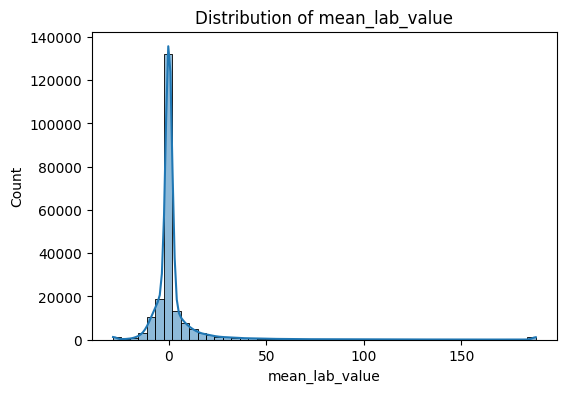

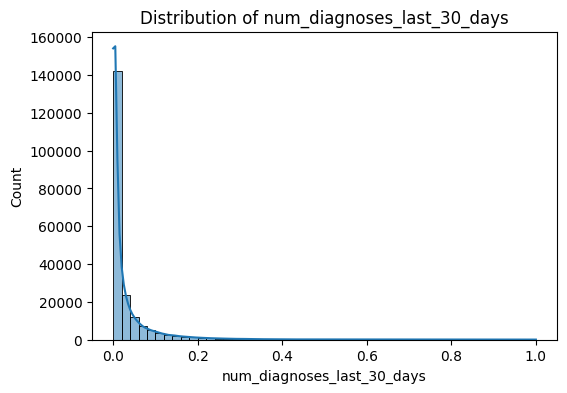

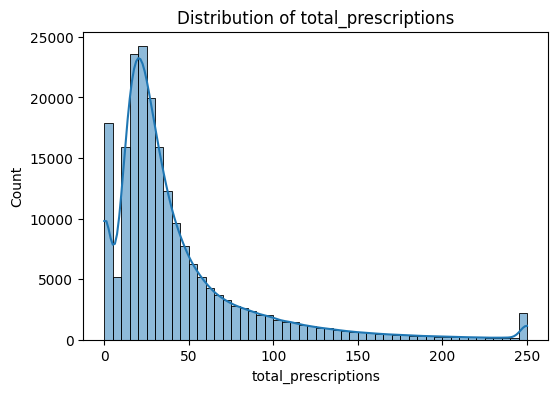

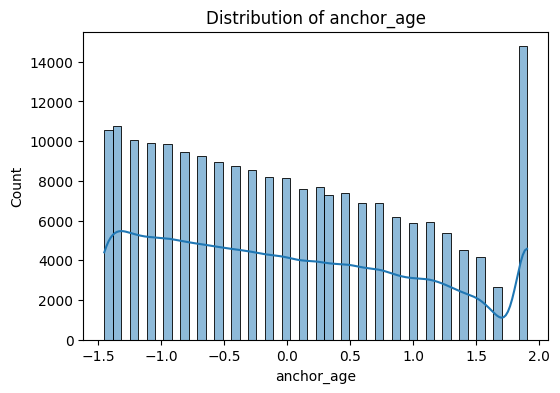


 Target Distribution (Readmitted in 30 Days):
readmitted_30d
0    80.963807
1    19.036193
Name: proportion, dtype: float64

 Outlier Summary:
mean_lab_value: 91974 outliers detected
num_diagnoses_last_30_days: 24439 outliers detected
total_prescriptions: 17731 outliers detected

 Data check complete - ready for modeling!


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data_path = '/content/drive/MyDrive/FYPData/scaled_for_linear_models.parquet'
data = pd.read_parquet(data_path)

# Shape and structure
print(f"Dataset Shape: {data.shape}")
print(data.info())

# Missing Values
missing_values = data.isnull().sum()
if missing_values.sum() == 0:
    print("\n No missing values detected.")
else:
    print("\n Missing Values:")
    print(missing_values[missing_values > 0])

# Data Types
print("\n Feature Data Types:")
print(data.dtypes)

# Feature Distributions
print("\n Feature Distributions:")
for column in ['mean_lab_value', 'num_diagnoses_last_30_days', 'total_prescriptions', 'anchor_age']:
    plt.figure(figsize=(6, 4))
    sns.histplot(data[column].dropna(), bins=50, kde=True)
    plt.title(f'Distribution of {column}')
    plt.show()

# Class Distribution
print("\n Target Distribution (Readmitted in 30 Days):")
print(data['readmitted_30d'].value_counts(normalize=True) * 100)

# Outlier Detection
print("\n Outlier Summary:")
outlier_cols = ['mean_lab_value', 'num_diagnoses_last_30_days', 'total_prescriptions']
for col in outlier_cols:
    q1, q3 = data[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower_bound, upper_bound = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_count = ((data[col] < lower_bound) | (data[col] > upper_bound)).sum()
    print(f"{col}: {outlier_count} outliers detected")

print("\n Data check complete - ready for modeling!")


In [ ]:
import pandas as pd

df['diag_freq'] = df['diag_freq'].fillna(0)
df['proc_freq'] = df['proc_freq'].fillna(0)

final_path = '/content/drive/MyDrive/FYPData/final_encoded_data.parquet'
df.to_parquet(final_path, index=False, compression='snappy')
print(" Saved final dfset ready for linear models to:", final_path)



 Saved final dfset ready for linear models to: /content/drive/MyDrive/FYPData/final_encoded_data.parquet


In [ ]:
import pandas as pd

data['diag_freq'] = data['diag_freq'].fillna(0)
data['proc_freq'] = data['proc_freq'].fillna(0)

final_path = '/content/drive/MyDrive/FYPData/scaled_final_linear_ready.parquet'
data.to_parquet(final_path, index=False, compression='snappy')
print(" Saved final dataset ready for linear models to:", final_path)

In [ ]:
import pandas as pd

data_path = '/content/drive/MyDrive/FYPData/scaled_final_linear_ready.parquet'  # or whichever you're working with
df = pd.read_parquet(data_path)

# Check missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if missing.empty:
    print(" No missing values detected.")
else:
    print(" Missing Values Found:")
    print(missing)


missing_percent = (df.isnull().mean() * 100).round(2)
missing_summary = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': missing_percent
}).query('`Missing Count` > 0').sort_values('Missing Count', ascending=False)

print(missing_summary)



 No missing values detected.
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


In [ ]:
import pandas as pd

df = pd.read_parquet('/content/drive/MyDrive/FYPData/scaled_final_linear_ready.parquet')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 2000)

df.head(10)


,hadm_id,subject_id,admittime,dischtime,anchor_age,mean_lab_value,min_lab_value,max_lab_value,total_lab_count,unique_lab_count,proportion_abnormal,total_prescriptions,unique_drug_count,total_doses,zero_dose_proportion,polypharmacy_flag,readmitted_30d,days_since_last_discharge,num_visits_last_90_days,same_day_readmission_flag,gap_flag,length_of_stay,num_diagnoses_last_30_days,num_diagnoses_last_60_days,num_diagnoses_last_90_days,num_prescriptions_last_30_days,num_prescriptions_last_60_days,num_prescriptions_last_90_days,num_procedures_last_30_days,num_procedures_last_60_days,num_procedures_last_90_days,num_unique_diagnoses,num_unique_procedures,age_bin,age_bin_encoded,insurance_missing,language_missing,marital_status_missing,mean_lab_value_missing,min_lab_value_missing,max_lab_value_missing,days_since_last_discharge_missing,length_of_stay_log,total_lab_count_log,total_prescriptions_log,has_diag_mapping,has_proc_mapping,diag_freq,diag_common_flag,proc_freq,proc_common_flag,lab_label_freq,lab_label_common_flag,admission_type_DIRECT EMER.,admission_type_DIRECT OBSERVATION,admission_type_ELECTIVE,admission_type_EU OBSERVATION,admission_type_EW EMER.,admission_type_OBSERVATION ADMIT,admission_type_SURGICAL SAME DAY ADMISSION,admission_type_URGENT,admission_location_CLINIC REFERRAL,admission_location_EMERGENCY ROOM,admission_location_INFORMATION NOT AVAILABLE,admission_location_INTERNAL TRANSFER TO OR FROM PSYCH,admission_location_PACU,admission_location_PHYSICIAN REFERRAL,admission_location_PROCEDURE SITE,admission_location_TRANSFER FROM HOSPITAL,admission_location_TRANSFER FROM SKILLED NURSING FACILITY,admission_location_WALK-IN/SELF REFERRAL,discharge_location_AGAINST ADVICE,discharge_location_ASSISTED LIVING,discharge_location_CHRONIC/LONG TERM ACUTE CARE,discharge_location_DIED,discharge_location_HOME,discharge_location_HOME HEALTH CARE,discharge_location_HOSPICE,discharge_location_OTHER FACILITY,discharge_location_Other,discharge_location_PSYCH FACILITY,discharge_location_REHAB,discharge_location_SKILLED NURSING FACILITY,insurance_Medicare,insurance_Other,insurance_Private,insurance_Unknown,language_Chinese,language_English,language_French,language_Haitian,language_Italian,language_Kabuverdianu,language_Korean,language_Modern Greek (1453-),language_Other,language_Persian,language_Polish,language_Portuguese,language_Russian,language_Somali,language_Spanish,language_Unknown,language_Vietnamese,marital_status_MARRIED,marital_status_SINGLE,marital_status_Unknown,marital_status_WIDOWED,race_ASIAN,race_ASIAN - ASIAN INDIAN,race_ASIAN - CHINESE,race_ASIAN - KOREAN,race_ASIAN - SOUTH EAST ASIAN,race_BLACK/AFRICAN,race_BLACK/AFRICAN AMERICAN,race_BLACK/CAPE VERDEAN,race_BLACK/CARIBBEAN ISLAND,race_HISPANIC OR LATINO,race_HISPANIC/LATINO - CENTRAL AMERICAN,race_HISPANIC/LATINO - COLUMBIAN,race_HISPANIC/LATINO - CUBAN,race_HISPANIC/LATINO - DOMINICAN,race_HISPANIC/LATINO - GUATEMALAN,race_HISPANIC/LATINO - HONDURAN,race_HISPANIC/LATINO - MEXICAN,race_HISPANIC/LATINO - PUERTO RICAN,race_HISPANIC/LATINO - SALVADORAN,race_MULTIPLE RACE/ETHNICITY,race_NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER,race_OTHER,race_PATIENT DECLINED TO ANSWER,race_PORTUGUESE,race_SOUTH AMERICAN,race_UNABLE TO OBTAIN,race_UNKNOWN,race_WHITE,race_WHITE - BRAZILIAN,race_WHITE - EASTERN EUROPEAN,race_WHITE - OTHER EUROPEAN,race_WHITE - RUSSIAN
0,23052089,10000084,2160-11-21 01:56:00,2160-11-25 14:52:00,-0.547242,0.000000,0.00,0.0,0.0,0.000000,0.342466,13.0,9.0,17.0,0.230769,1.0,0,93.0,0,0,0,4,0.000050,0.000050,0.000050,0.000003,0.000003,0.000003,0.000000,0.000000,0.000000,6,0,65-74,0,0,0,0,1,1,1,1,1.609438,0.000000,2.639057,1,1,0.005217,1,0.000000,0,0.552337,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
1,29888819,10000084,2160-12-28 05:11:00,2160-12-28 16:07:00,-0.547242,0.000000,0.00,0.0,0.0,0.000000,0.342466,0.0,0.0,0.0,0.000000,0.0,0,32.0,

In [ ]:
# Drop column with no variance
df.drop(columns=['discharge_location_DIED'], inplace=True)

df.to_parquet('/content/drive/MyDrive/FYPData/final_linear_data_ready_for_modelling.parquet', index=False)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from imblearn.combine import SMOTETomek
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, roc_auc_score, f1_score, recall_score, precision_score
)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import EditedNearestNeighbours

data_path = '/content/drive/MyDrive/FYPData/final_linear_data_ready_for_modelling.parquet'
data = pd.read_parquet(data_path, engine='pyarrow')

# Inspect Data for Potential Anomalies
def inspect_data(data):
    print(f"Data Shape: {data.shape}")
    print(f"Missing Values:")
    print(data.isna().sum())
    print(f"Class Distribution:")
    print(data['readmitted_30d'].value_counts(normalize=True))



inspect_data(data)

Data Shape: (205456, 139)
Missing Values:
hadm_id                          0
subject_id                       0
admittime                        0
dischtime                        0
anchor_age                       0
                                ..
race_WHITE                       0
race_WHITE - BRAZILIAN           0
race_WHITE - EASTERN EUROPEAN    0
race_WHITE - OTHER EUROPEAN      0
race_WHITE - RUSSIAN             0
Length: 139, dtype: int64
Class Distribution:
readmitted_30d
0    0.809638
1    0.190362
Name: proportion, dtype: float64


,0
hadm_id,int32
subject_id,int32
admittime,datetime64[ns]
dischtime,datetime64[ns]
anchor_age,float32
...,...
race_WHITE,int8
race_WHITE - BRAZILIAN,int8
race_WHITE - EASTERN EUROPEAN,int8
race_WHITE - OTHER EUROPEAN,int8


In [ ]:
import pandas as pd

df = pd.read_parquet('/content/drive/MyDrive/FYPData/final_linear_data_ready_for_modelling.parquet')

# Show data types summary
print(" Column Data Types:\n")
print(df.dtypes.value_counts())
print("\n Example of each type:\n")
print(df.dtypes.sample(10))


 Column Data Types:

int8              87
float64           22
int64             13
float32            6
int16              6
datetime64[ns]     2
int32              2
category           1
Name: count, dtype: int64

 Example of each type:

language_missing                                               int64
language_Haitian                                                int8
days_since_last_discharge_missing                              int64
max_lab_value_missing                                          int64
discharge_location_Other                                        int8
discharge_location_HOME                                         int8
num_diagnoses_last_90_days                                   float64
race_HISPANIC/LATINO - CENTRAL AMERICAN                         int8
discharge_location_PSYCH FACILITY                               int8
admission_location_TRANSFER FROM SKILLED NURSING FACILITY       int8
dtype: object


In [ ]:
df = df.dropna(subset=['length_of_stay_log']).reset_index(drop=True)


In [ ]:
df.to_parquet('/content/drive/MyDrive/FYPData/final_linear_data_ready_for_modelling.parquet', index=False)

In [ ]:
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_rows', 100)      # Increase if needed
pd.set_option('display.width', 2000)        # Prevent wrapping

print(df.head(10))

    hadm_id  subject_id           admittime           dischtime  anchor_age  mean_lab_value  min_lab_value  max_lab_value  total_lab_count  unique_lab_count  proportion_abnormal  total_prescriptions  unique_drug_count  total_doses  zero_dose_proportion  polypharmacy_flag  readmitted_30d  days_since_last_discharge  num_visits_last_90_days  same_day_readmission_flag  gap_flag  length_of_stay  num_diagnoses_last_30_days  num_diagnoses_last_60_days  num_diagnoses_last_90_days  num_prescriptions_last_30_days  num_prescriptions_last_60_days  num_prescriptions_last_90_days  num_procedures_last_30_days  num_procedures_last_60_days  num_procedures_last_90_days  num_unique_diagnoses  num_unique_procedures age_bin  age_bin_encoded  insurance_missing  language_missing  marital_status_missing  mean_lab_value_missing  min_lab_value_missing  max_lab_value_missing  days_since_last_discharge_missing  length_of_stay_log  total_lab_count_log  total_prescriptions_log  has_diag_mapping  has_proc_mapping  d

# Aligning to Notes Patients for Analysis

In [ ]:
import pandas as pd

structured = pd.read_parquet("/content/drive/MyDrive/FYPData/final_encoded_data.parquet")

# Load the same notes dataset used for ClinicalBERT fine-tuning to align for comparison
notes_df = pd.read_csv("/content/drive/MyDrive/FYPData/notes_ready_for_finetuning_extracted.csv")

notes_df = notes_df.dropna(subset=["clean_text"]).reset_index(drop=True)

# Filter structured data to match hadm_ids in the notes
hadm_ids_used = notes_df["hadm_id"].unique()
structured_matched = structured[structured["hadm_id"].isin(hadm_ids_used)].reset_index(drop=True)

structured_matched.to_parquet("/content/drive/MyDrive/FYPData/structured_matched_to_notes.parquet", index=False)

print(f" Structured data aligned to notes. Shape: {structured_matched.shape}")


 Structured data aligned to notes. Shape: (140819, 140)


In [ ]:
import pandas as pd

structured = pd.read_parquet("/content/drive/MyDrive/FYPData/final_linear_data_ready_for_modelling.parquet")

notes_df = pd.read_csv("/content/drive/MyDrive/FYPData/notes_ready_for_finetuning_extracted.csv")

notes_df = notes_df.dropna(subset=["clean_text"]).reset_index(drop=True)

hadm_ids_used = notes_df["hadm_id"].unique()
structured_matched = structured[structured["hadm_id"].isin(hadm_ids_used)].reset_index(drop=True)

structured_matched.to_parquet("/content/drive/MyDrive/FYPData/structured_linear_matched_to_notes.parquet", index=False)

print(f" Structured data aligned to notes. Shape: {structured_matched.shape}")


 Structured data aligned to notes. Shape: (140819, 139)


# SMOTE & Traditional Modelling

In [ ]:
import pandas as pd
import numpy as np
import os
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    classification_report, roc_auc_score, f1_score,
    recall_score, precision_score, precision_recall_curve
)
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold
from imblearn.combine import SMOTEENN
from scipy.stats import randint
import warnings
warnings.filterwarnings('ignore')

data = pd.read_parquet('/content/drive/MyDrive/FYPData/structured_matched_to_notes.parquet')

# Memory Optimization
float_cols = data.select_dtypes(include='float').columns
int_cols = data.select_dtypes(include='int').columns
data[float_cols] = data[float_cols].astype(np.float32)
data[int_cols] = data[int_cols].astype(np.int16)

# Define Features and Target
X = data.drop(['readmitted_30d', 'subject_id', 'hadm_id', 'admittime', 'dischtime', 'discharge_location_DIED', 'age_bin'], axis=1)
y = data['readmitted_30d']

# Train-Test Split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
)

# Feature Selection
constant_filter = VarianceThreshold(threshold=0)
X_train_filtered = constant_filter.fit_transform(X_train_raw)
X_test_filtered = constant_filter.transform(X_test_raw)

k_best_selector = SelectKBest(score_func=f_classif, k=80)
X_train_selected = k_best_selector.fit_transform(X_train_filtered, y_train)
X_test_selected = k_best_selector.transform(X_test_filtered)

selected_features = X_train_raw.columns[constant_filter.get_support()][k_best_selector.get_support()]
X_train_df = pd.DataFrame(X_train_selected, columns=selected_features)
X_test_df = pd.DataFrame(X_test_selected, columns=selected_features)

X_train_df.fillna(X_train_df.median(), inplace=True)
X_test_df.fillna(X_train_df.median(), inplace=True)

# SMOTEENN
print("Running batch-wise SMOTEENN for Random Forest...")
batch_size = 250_000
X_batches, y_batches = [], []

for i in range(0, len(X_train_df), batch_size):
    X_batch = X_train_df.iloc[i:i + batch_size]
    y_batch = y_train.iloc[i:i + batch_size]

    print(f"Batch {i // batch_size + 1}")
    X_res, y_res = SMOTEENN(sampling_strategy=0.5, n_jobs=-1).fit_resample(X_batch, y_batch)
    X_batches.append(X_res)
    y_batches.append(y_res)

X_rf_resampled = pd.concat(X_batches, axis=0)
y_rf_resampled = pd.concat(y_batches, axis=0)
X_rf_resampled.columns = selected_features

# Randomized Search for Hyperparameters
param_dist = {
    'n_estimators': randint(100, 300),
    'max_depth': randint(10, 30),
    'min_samples_split': randint(2, 15),
    'max_features': ['sqrt', 'log2', 0.2, 0.5],
    'class_weight': ['balanced_subsample']
}

rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)

search = RandomizedSearchCV(
    rf_model,
    param_distributions=param_dist,
    scoring='roc_auc',
    n_iter=20,
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_rf_resampled, y_rf_resampled)
best_rf = search.best_estimator_
print("Best Parameters:", search.best_params_)

# Threshold tuning
y_pred_prob = best_rf.predict_proba(X_test_df)[:, 1]
prec, rec, thresholds = precision_recall_curve(y_test, y_pred_prob)
f1_scores = 2 * (prec * rec) / (prec + rec + 1e-6)
best_thresh = thresholds[np.argmax(f1_scores)]
print(f"\nOptimal Threshold based on F1: {best_thresh:.3f}")

y_pred = (y_pred_prob >= best_thresh).astype(int)

# Evaluation
print("\nEvaluation Results on Test Set:")
print(f"Test AUROC: {roc_auc_score(y_test, y_pred_prob):.4f}")
print(f"Test F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"Test Recall: {recall_score(y_test, y_pred):.4f}")
print(f"Test Precision: {precision_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

# Feature Importance
importances_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nTop 20 Features by Importance:")
print(importances_df.head(20))

# Export Outputs
results_path = '/content/drive/MyDrive/FYPData/Model_Results/'
os.makedirs(results_path, exist_ok=True)

joblib.dump(best_rf, results_path + 'random_forest_optimized_model.joblib')
X_rf_resampled.to_parquet(results_path + 'X_rf_resampled.parquet', index=False)
y_rf_resampled.to_frame(name='readmitted_30d').to_parquet(results_path + 'y_rf_resampled.parquet', index=False)
pd.DataFrame({'y_true': y_test, 'y_pred': y_pred, 'y_prob': y_pred_prob}).to_csv(results_path + 'rf_test_predictions.csv', index=False)
importances_df.to_csv(results_path + 'rf_feature_importance.csv', index=False)

print("\n All outputs saved to:", results_path)


Running batch-wise SMOTEENN for Random Forest...
Batch 1
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters: {'class_weight': 'balanced_subsample', 'max_depth': 24, 'max_features': 0.2, 'min_samples_split': 2, 'n_estimators': 263}

Optimal Threshold based on F1: 0.172

Evaluation Results on Test Set:
Test AUROC: 0.6655
Test F1 Score: 0.4000
Test Recall: 0.6174
Test Precision: 0.2958

Classification Report:
              precision    recall  f1-score   support

           0     0.8688    0.6327    0.7322     11267
           1     0.2958    0.6174    0.4000      2815

    accuracy                         0.6297     14082
   macro avg     0.5823    0.6251    0.5661     14082
weighted avg     0.7542    0.6297    0.6658     14082


Top 20 Features by Importance:
                                  Feature  Importance
11              days_since_last_discharge    0.113698
12                num_visits_last_90_days    0.062070
17                  num_unique_procedures  

In [ ]:
import pandas as pd
import numpy as np

rf_preds = pd.read_csv('/content/drive/MyDrive/FYPData/Model_Results/rf_test_predictions.csv')

np.save('/content/drive/MyDrive/FYPData/Model_Results/rf_test_probs.npy', rf_preds['y_prob'].values)
np.save('/content/drive/MyDrive/FYPData/Model_Results/rf_test_labels.npy', rf_preds['y_true'].values)

print("Saved from CSV!")


Saved from CSV!


In [ ]:
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, precision_recall_curve, auc
)

probs_rf = np.load('/content/drive/MyDrive/FYPData/Model_Results/rf_test_probs.npy')
labels_rf = np.load('/content/drive/MyDrive/FYPData/Model_Results/rf_test_labels.npy')

best_rf_threshold = 0.172

# Predict labels
preds_rf = (probs_rf >= best_rf_threshold).astype(int)

# Evaluate
print("\n=== Verification of Random Forest Saved Outputs ===")
print(f"Accuracy : {accuracy_score(labels_rf, preds_rf):.4f}")
print(f"Precision: {precision_score(labels_rf, preds_rf):.4f}")
print(f"Recall   : {recall_score(labels_rf, preds_rf):.4f}")
print(f"F1 Score : {f1_score(labels_rf, preds_rf):.4f}")
print(f"AUROC    : {roc_auc_score(labels_rf, probs_rf):.4f}")

# PR AUC
precision, recall, _ = precision_recall_curve(labels_rf, probs_rf)
pr_auc = auc(recall, precision)
print(f"PR AUC   : {pr_auc:.4f}")

print("\nClassification Report:\n")
print(classification_report(labels_rf, preds_rf, digits=4))



=== Verification of Random Forest Saved Outputs ===
Accuracy : 0.6295
Precision: 0.2956
Recall   : 0.6174
F1 Score : 0.3998
AUROC    : 0.6655
PR AUC   : 0.3445

Classification Report:

              precision    recall  f1-score   support

           0     0.8687    0.6325    0.7320     11267
           1     0.2956    0.6174    0.3998      2815

    accuracy                         0.6295     14082
   macro avg     0.5822    0.6249    0.5659     14082
weighted avg     0.7541    0.6295    0.6656     14082



In [ ]:
import pandas as pd
import numpy as np
import os
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import classification_report, roc_auc_score, f1_score, recall_score, precision_score, precision_recall_curve
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold
from sklearn.preprocessing import PolynomialFeatures
from imblearn.combine import SMOTEENN
import warnings
warnings.filterwarnings('ignore')

data = pd.read_parquet('/content/drive/MyDrive/FYPData/structured_linear_matched_to_notes.parquet')

float_cols = data.select_dtypes(include='float').columns
int_cols = data.select_dtypes(include='int').columns
data[float_cols] = data[float_cols].astype(np.float32)
data[int_cols] = data[int_cols].astype(np.int16)

# Define Features and Target
X = data.drop(['readmitted_30d', 'subject_id', 'hadm_id', 'admittime', 'dischtime', 'age_bin'], axis=1)
y = data['readmitted_30d']

# Train-Test Split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
)

# Feature Selection
constant_filter = VarianceThreshold(threshold=0)
X_train_filtered = constant_filter.fit_transform(X_train_raw)
X_test_filtered = constant_filter.transform(X_test_raw)

k_best_selector = SelectKBest(score_func=f_classif, k=80)
X_train_selected = k_best_selector.fit_transform(X_train_filtered, y_train)
X_test_selected = k_best_selector.transform(X_test_filtered)

original_features = X_train_raw.columns[constant_filter.get_support()]
selected_features = original_features[k_best_selector.get_support()]
X_train_df = pd.DataFrame(X_train_selected, columns=selected_features)
X_test_df = pd.DataFrame(X_test_selected, columns=selected_features)

X_train_df.fillna(X_train_df.median(), inplace=True)
X_test_df.fillna(X_train_df.median(), inplace=True)

# Add Interaction Features
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_train_poly = poly.fit_transform(X_train_df)
X_test_poly = poly.transform(X_test_df)
poly_feature_names = poly.get_feature_names_out(input_features=selected_features)

# SMOTEENN
print("Running batch-wise SMOTEENN for Logistic Regression with Interactions...")
batch_size = 250_000
X_batches, y_batches = [], []

for i in range(0, len(X_train_poly), batch_size):
    X_batch = X_train_poly[i:i + batch_size]
    y_batch = y_train.iloc[i:i + batch_size]

    print(f"Batch {i // batch_size + 1}")
    X_res, y_res = SMOTEENN(sampling_strategy=0.5, n_jobs=-1).fit_resample(X_batch, y_batch)
    X_batches.append(X_res)
    y_batches.append(y_res)

X_lr_resampled = np.vstack(X_batches)
y_lr_resampled = pd.concat(y_batches, axis=0)

# Logistic Regression
lr_model = LogisticRegression(
    solver='saga',
    penalty='elasticnet',
    l1_ratio=0.5,
    class_weight='balanced',
    random_state=42,
    max_iter=200,
    tol=1e-3,
    warm_start=True,
    n_jobs=-1,
    verbose=2
)

# Cross-validation
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_auc = cross_val_score(lr_model, X_lr_resampled, y_lr_resampled, cv=cv, scoring='roc_auc')
print(f"\nCross-Validation AUROC: {np.mean(cv_auc):.4f}")

# Fit on full resampled data
lr_model.fit(X_lr_resampled, y_lr_resampled)

# Test evaluation
y_pred_prob = lr_model.predict_proba(X_test_poly)[:, 1]
prec, rec, thresholds = precision_recall_curve(y_test, y_pred_prob)
f1_scores = 2 * (prec * rec) / (prec + rec + 1e-6)
best_thresh = thresholds[np.argmax(f1_scores)]
print(f"\nOptimal Threshold based on F1: {best_thresh:.3f}")

# Predict with tuned threshold
y_pred = (y_pred_prob >= best_thresh).astype(int)
print("\nEvaluation Results on Test Set:")
print(f"Test AUROC: {roc_auc_score(y_test, y_pred_prob):.4f}")
print(f"Test F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"Test Recall: {recall_score(y_test, y_pred):.4f}")
print(f"Test Precision: {precision_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

# Export Results
results_path = '/content/drive/MyDrive/FYPData/Model_Results/'
os.makedirs(results_path, exist_ok=True)

joblib.dump(lr_model, results_path + 'logistic_regression_poly_model.joblib')
np.save(results_path + 'X_lr_resampled.npy', X_lr_resampled)
y_lr_resampled.to_frame(name='readmitted_30d').to_parquet(results_path + 'y_lr_resampled.parquet', index=False)
pd.DataFrame({'y_true': y_test, 'y_pred': y_pred, 'y_prob': y_pred_prob}).to_csv(results_path + 'lr_test_predictions.csv', index=False)
pd.DataFrame({'Feature': poly_feature_names, 'Coefficient': lr_model.coef_.flatten()}).to_csv(results_path + 'lr_poly_feature_importance.csv', index=False)

print("\n All outputs saved to:", results_path)




Running batch-wise SMOTEENN for Logistic Regression with Interactions...
Batch 1


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.


max_iter reached after 455 seconds


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.


max_iter reached after 452 seconds


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.


max_iter reached after 455 seconds

Cross-Validation AUROC: 0.6550


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.


max_iter reached after 684 seconds

Optimal Threshold based on F1: 0.497

Evaluation Results on Test Set:
Test AUROC: 0.5973
Test F1 Score: 0.3634
Test Recall: 0.6405
Test Precision: 0.2536

Classification Report:
              precision    recall  f1-score   support

           0     0.8549    0.5291    0.6536     11267
           1     0.2536    0.6405    0.3634      2815

    accuracy                         0.5513     14082
   macro avg     0.5542    0.5848    0.5085     14082
weighted avg     0.7347    0.5513    0.5956     14082


 All outputs saved to: /content/drive/MyDrive/FYPData/Model_Results/


In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif

results_path = '/content/drive/MyDrive/FYPData/Model_Results/'

lr_model = joblib.load(results_path + 'logistic_regression_poly_model.joblib')
feature_importance_df = pd.read_csv(results_path + 'lr_poly_feature_importance.csv')

poly_feature_names = feature_importance_df['Feature'].tolist()
coefficients = feature_importance_df['Coefficient'].values

data = pd.read_parquet('/content/drive/MyDrive/FYPData/structured_linear_matched_to_notes.parquet')

float_cols = data.select_dtypes(include='float').columns
int_cols = data.select_dtypes(include='int').columns
data[float_cols] = data[float_cols].astype(np.float32)
data[int_cols] = data[int_cols].astype(np.int16)

X = data.drop(['readmitted_30d', 'subject_id', 'hadm_id', 'admittime', 'dischtime', 'age_bin'], axis=1)
y = data['readmitted_30d']

# Train-Test Split (Same as Original: 10% test, stratified)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
)

constant_filter = VarianceThreshold(threshold=0)
X_train_filtered = constant_filter.fit_transform(X_train_raw)
X_test_filtered = constant_filter.transform(X_test_raw)

k_best_selector = SelectKBest(score_func=f_classif, k=80)
X_train_selected = k_best_selector.fit_transform(X_train_filtered, y_train)
X_test_selected = k_best_selector.transform(X_test_filtered)

original_features = X_train_raw.columns[constant_filter.get_support()]
selected_features = original_features[k_best_selector.get_support()]
X_train_df = pd.DataFrame(X_train_selected, columns=selected_features)
X_test_df = pd.DataFrame(X_test_selected, columns=selected_features)

X_test_df.fillna(X_train_df.median(), inplace=True)

poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)

X_train_poly = poly.fit_transform(X_train_df)
poly_feature_names = poly.get_feature_names_out(selected_features)

X_test_poly = poly.transform(X_test_df)

# Correlation Calculation
X_test_poly_df = pd.DataFrame(X_test_poly, columns=poly_feature_names)
X_test_poly_df['readmitted_30d'] = y_test.reset_index(drop=True)

# Calculate correlations
readmit_labels = X_test_poly_df['readmitted_30d'].values
correlations = {}

for feature in poly_feature_names:
    feature_values = X_test_poly_df[feature].values
    correlations[feature] = np.corrcoef(feature_values, readmit_labels)[0, 1]

# Convert to Series
correlations = pd.Series(correlations)


# Combine Coefficients and Correlations
coef_corr_df = pd.DataFrame({
    'Feature': poly_feature_names,
    'Coefficient': coefficients,
    'Correlation_with_Readmit': correlations.values
})

# Filter and Sort Top 20
positive_corr_df = coef_corr_df[coef_corr_df['Correlation_with_Readmit'] > 0]

top_20_positive_corr_features = positive_corr_df.reindex(
    positive_corr_df['Coefficient'].abs().sort_values(ascending=False).index
).head(20)

print("\nTop 20 Features: Positive Correlation with Readmission and Largest Coefficients")
print(top_20_positive_corr_features[['Feature', 'Coefficient', 'Correlation_with_Readmit']])

top_20_positive_corr_features.to_csv(results_path + 'top_20_features_logistic_poly.csv', index=False)
print("\nTop 20 features saved to:", results_path + 'top_20_features_logistic_poly.csv')


/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



Top 20 Features: Positive Correlation with Readmission and Largest Coefficients
                                           Feature  Coefficient  \
322        total_lab_count num_visits_last_90_days     0.000033   
246          max_lab_value num_visits_last_90_days     0.000029   
544    total_prescriptions num_visits_last_90_days     0.000026   
687            total_doses num_visits_last_90_days     0.000026   
691               total_doses num_unique_diagnoses     0.000018   
548       total_prescriptions num_unique_diagnoses     0.000015   
258              max_lab_value total_lab_count_log     0.000015   
897       days_since_last_discharge length_of_stay     0.000014   
616      unique_drug_count num_visits_last_90_days     0.000014   
620         unique_drug_count num_unique_diagnoses     0.000014   
965   num_visits_last_90_days num_unique_diagnoses     0.000012   
240              max_lab_value total_prescriptions    -0.000012   
241                max_lab_value unique_drug_cou

In [ ]:
import pandas as pd
import numpy as np

lr_preds = pd.read_csv('/content/drive/MyDrive/FYPData/Model_Results/lr_test_predictions.csv')

np.save('/content/drive/MyDrive/FYPData/Model_Results/lr_test_probs.npy', lr_preds['y_prob'].values)
np.save('/content/drive/MyDrive/FYPData/Model_Results/lr_test_labels.npy', lr_preds['y_true'].values)

print("Saved Logistic Regression test probs and labels!")


Saved Logistic Regression test probs and labels!


In [ ]:
import pandas as pd
import numpy as np
import os
import joblib
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import classification_report, roc_auc_score, f1_score, recall_score, precision_score, precision_recall_curve
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold
from imblearn.combine import SMOTEENN
from scipy.stats import randint, uniform
import warnings
warnings.filterwarnings('ignore')

data = pd.read_parquet('/content/drive/MyDrive/FYPData/structured_matched_to_notes.parquet')

float_cols = data.select_dtypes(include='float').columns
int_cols = data.select_dtypes(include='int').columns
data[float_cols] = data[float_cols].astype(np.float32)
data[int_cols] = data[int_cols].astype(np.int16)

X = data.drop(['readmitted_30d', 'subject_id', 'hadm_id', 'admittime', 'dischtime', 'discharge_location_DIED', 'age_bin'], axis=1)
y = data['readmitted_30d']

# Train-Test Split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.1, stratify=y, random_state=42)

# Feature Selection
constant_filter = VarianceThreshold(threshold=0)
X_train_filtered = constant_filter.fit_transform(X_train_raw)
X_test_filtered = constant_filter.transform(X_test_raw)

k_best_selector = SelectKBest(score_func=f_classif, k=80)
X_train_selected = k_best_selector.fit_transform(X_train_filtered, y_train)
X_test_selected = k_best_selector.transform(X_test_filtered)

original_features = X_train_raw.columns[constant_filter.get_support()]
selected_features = original_features[k_best_selector.get_support()]
X_train_df = pd.DataFrame(X_train_selected, columns=selected_features)
X_test_df = pd.DataFrame(X_test_selected, columns=selected_features)

X_train_df.fillna(X_train_df.median(), inplace=True)
X_test_df.fillna(X_train_df.median(), inplace=True)

# SMOTEENN
print("Running batch-wise SMOTEENN for XGBoost...")
batch_size = 250_000
X_batches, y_batches = [], []
for i in range(0, len(X_train_df), batch_size):
    X_batch = X_train_df.iloc[i:i + batch_size]
    y_batch = y_train.iloc[i:i + batch_size]
    print(f"Batch {i // batch_size + 1}")
    X_res, y_res = SMOTEENN(sampling_strategy=0.4, n_jobs=-1).fit_resample(X_batch, y_batch)
    X_batches.append(X_res)
    y_batches.append(y_res)

X_xgb_resampled = pd.concat(X_batches, axis=0)
y_xgb_resampled = pd.concat(y_batches, axis=0)
X_xgb_resampled.columns = selected_features

# XGBoost with RandomizedSearchCV
xgb = XGBClassifier(objective='binary:logistic',
                    use_label_encoder=False,
                    eval_metric='auc',
                    tree_method='hist',
                    random_state=42)

param_dist = {
    'n_estimators': randint(150, 400),                       # more trees help deeper patterns
    'max_depth': randint(10, 20),                            # focus on deeper trees
    'learning_rate': uniform(0.005, 0.05),                   # lower rates for smoother learning
    'subsample': uniform(0.6, 0.3),                          # focus on moderately sub-sampled
    'colsample_bytree': uniform(0.6, 0.3),
    'min_child_weight': [1, 3, 5],                           # good spread for regularization
    'scale_pos_weight': [1, 2],                              # low imbalance due to SMOTEENN
    'gamma': uniform(0.1, 0.9),                              # add regularization to splits
    'reg_alpha': uniform(0.001, 0.2),                        # L1 regularization
    'reg_lambda': uniform(0.1, 0.9)                          # L2 regularization
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

rs = RandomizedSearchCV(
    xgb, param_distributions=param_dist,
    n_iter=100, scoring='roc_auc', n_jobs=-1,
    cv=cv, verbose=2, random_state=42
)

rs.fit(X_xgb_resampled, y_xgb_resampled)


print("Best Parameters:", rs.best_params_)
best_xgb = rs.best_estimator_

# Evaluate on Test Set
y_pred_prob = best_xgb.predict_proba(X_test_df)[:, 1]
prec, rec, thresholds = precision_recall_curve(y_test, y_pred_prob)
f1_scores = 2 * (prec * rec) / (prec + rec + 1e-6)
best_thresh = thresholds[np.argmax(f1_scores)]
print(f"\nOptimal Threshold based on F1: {best_thresh:.3f}")

y_pred = (y_pred_prob >= best_thresh).astype(int)

print("\nEvaluation Results on Test Set:")
print(f"Test AUROC: {roc_auc_score(y_test, y_pred_prob):.4f}")
print(f"Test F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"Test Recall: {recall_score(y_test, y_pred):.4f}")
print(f"Test Precision: {precision_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

# Feature Importance
importances_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance': best_xgb.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nTop 20 Features by Importance:")
print(importances_df.head(20))

results_path = '/content/drive/MyDrive/FYPData/Model_Results/'
os.makedirs(results_path, exist_ok=True)

joblib.dump(best_xgb, results_path + 'xgboost_optimized_model.joblib')
X_xgb_resampled.to_parquet(results_path + 'X_xgb_resampled.parquet', index=False)
y_xgb_resampled.to_frame(name='readmitted_30d').to_parquet(results_path + 'y_xgb_resampled.parquet', index=False)
pd.DataFrame({'y_true': y_test, 'y_pred': y_pred, 'y_prob': y_pred_prob}).to_csv(results_path + 'xgb_test_predictions.csv', index=False)
importances_df.to_csv(results_path + 'xgb_feature_importance.csv', index=False)

print("\n All XGBoost outputs saved to:", results_path)

Running batch-wise SMOTEENN for XGBoost...
Batch 1
Fitting 3 folds for each of 100 candidates, totalling 300 fits
Best Parameters: {'colsample_bytree': np.float64(0.7624343921482697), 'gamma': np.float64(0.726205959410574), 'learning_rate': np.float64(0.016427501089864984), 'max_depth': 19, 'min_child_weight': 1, 'n_estimators': 393, 'reg_alpha': np.float64(0.10693011567120131), 'reg_lambda': np.float64(0.3176670618104065), 'scale_pos_weight': 2, 'subsample': np.float64(0.889625805386638)}

Optimal Threshold based on F1: 0.039

Evaluation Results on Test Set:
Test AUROC: 0.6677
Test F1 Score: 0.3968
Test Recall: 0.6579
Test Precision: 0.2840

Classification Report:
              precision    recall  f1-score   support

           0     0.8727    0.5857    0.7009     11267
           1     0.2840    0.6579    0.3968      2815

    accuracy                         0.6001     14082
   macro avg     0.5784    0.6218    0.5489     14082
weighted avg     0.7550    0.6001    0.6401     14082


In [ ]:
import pandas as pd
import numpy as np

xgb_preds = pd.read_csv('/content/drive/MyDrive/FYPData/Model_Results/xgb_test_predictions.csv')

np.save('/content/drive/MyDrive/FYPData/Model_Results/xgb_test_probs.npy', xgb_preds['y_prob'].values)
np.save('/content/drive/MyDrive/FYPData/Model_Results/xgb_test_labels.npy', xgb_preds['y_true'].values)

print("Saved XGBoost test probs and labels!")


Saved XGBoost test probs and labels!


# Downloading Clincial Notes with Initial Preprocessing

In [ ]:
!wget -O /content/drive/MyDrive/FYPData/mimiciv/discharge.csv.gz --user=markmckeon11 --ask-password "https://physionet.org/files/mimic-iv-note/2.2/note/discharge.csv.gz?download"


Password for user ‘markmckeon11’: 
--2025-02-25 12:06:47--  https://physionet.org/files/mimic-iv-note/2.2/note/discharge.csv.gz?download
Resolving physionet.org (physionet.org)... 18.18.42.54
Connecting to physionet.org (physionet.org)|18.18.42.54|:443... connected.
HTTP request sent, awaiting response... 401 Unauthorized
Authentication selected: Basic realm="PhysioNet", charset="UTF-8"
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 1139203149 (1.1G) [application/gzip]
Saving to: ‘/content/drive/MyDrive/FYPData/mimiciv/discharge.csv.gz’

/content/drive/MyDr 100%[===================>]   1.06G   424KB/s    in 40m 40s 

2025-02-25 12:47:28 (456 KB/s) - ‘/content/drive/MyDrive/FYPData/mimiciv/discharge.csv.gz’ saved [1139203149/1139203149]



In [ ]:
import pandas as pd
import gzip
import os
from concurrent.futures import ProcessPoolExecutor
import glob

# Set paths
file_path = "/content/drive/MyDrive/FYPData/mimiciv/discharge.csv.gz"
output_dir = "/content/drive/MyDrive/FYPData/mimiciv/processed_chunks"
os.makedirs(output_dir, exist_ok=True)

# Parameters
num_workers = 8
chunk_size = 500_000

# Function to process each chunk
def process_chunk(chunk_id, chunk_data):
    print(f"Processing chunk {chunk_id} with {len(chunk_data)} rows...")

    # Select relevant columns
    cleaned_data = chunk_data[['subject_id', 'hadm_id', 'text']]

    # Save chunk
    chunk_path = f"{output_dir}/chunk_{chunk_id}.csv"
    cleaned_data.to_csv(chunk_path, index=False)
    return f"Chunk {chunk_id} saved: {chunk_path}"

# Function to read and process the gzip file in parallel
def parallel_process_gzip(file_path, chunk_size, num_workers):
    with gzip.open(file_path, 'rt', encoding="utf-8") as f:
        reader = pd.read_csv(f, chunksize=chunk_size)

        with ProcessPoolExecutor(max_workers=num_workers) as executor:
            futures = []
            for chunk_id, chunk in enumerate(reader):
                futures.append(executor.submit(process_chunk, chunk_id, chunk))

            for future in futures:
                print(future.result())

# Run chunked processing
parallel_process_gzip(file_path, chunk_size, num_workers)

# Combine all processed chunks into one final file
csv_files = glob.glob(f"{output_dir}/*.csv")
final_df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)

final_df.to_csv(f"{output_dir}/final_discharge.csv", index=False)
print(" Final CSV saved at:", f"{output_dir}/final_discharge.csv")


Processing chunk 0 with 331793 rows...
Chunk 0 saved: /content/drive/MyDrive/FYPData/mimiciv/processed_chunks/chunk_0.csv
 Final CSV saved at: /content/drive/MyDrive/FYPData/mimiciv/processed_chunks/final_discharge.csv


In [ ]:
!pip install transformers datasets torch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 485.4/485.4 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 86.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 72.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 71.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/FYPData/mimiciv/processed_chunks/final_discharge.csv"

df = pd.read_csv(file_path)

df.head()


,subject_id,hadm_id,text
0,10000032,22595853,\nName: ___ Unit No: _...
1,10000032,22841357,\nName: ___ Unit No: _...
2,10000032,29079034,\nName: ___ Unit No: _...
3,10000032,25742920,\nName: ___ Unit No: _...
4,10000084,23052089,\nName: ___ Unit No: __...
